In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Acceleration? {device}")

Acceleration? cuda


In [9]:
csv_data = """
id,name,description,boardgamecategory,boardgamemechanic,boardgamedesigner,usersrated,rating,bayes_rating,num_comments,playtime,min_playtime,max_playtime
13,CATAN,"In CATAN (formerly The Settlers of Catan), players try to be the dominant force on the island of Catan by building settlements, cities and roads. On each turn dice are rolled to determine which resources the island produces. Players build structures by 'spending' resources (sheep, wheat, wood, brick and ore) which are represented by the relevant resource cards; each land type, with the exception of the unproductive desert, produces a specific resource: hills produce brick, forests produce wood, mountains produce ore, fields produce wheat, and pastures produce sheep.&#10;&#10;Set-up includes randomly placing large hexagonal tiles (each depicting one of the five resource-producing terrain types--or the desert) in a honeycomb shape and surrounding them with water tiles, some of which contain ports of exchange. A number disk, the value of which will correspond to the roll of two 6-sided dice, are placed on each terrain tile. Each player is given two settlements (think: houses) and roads (sticks) which are placed on intersections and borders of the terrain tiles. Players collect a hand of resource cards based on which terrain tiles their last-placed settlement is adjacent to. A robber pawn is placed on the desert tile.&#10;&#10;A turn consists of rolling the dice, collecting resource cards based on this dice roll and the position of settlements (or upgraded cities&mdash;think: hotels), turning in resource cards (if possible and desired) for improvements, trading cards at a port, possibly playing a development card, or trading resource cards with other players. If the dice roll is a 7, the active player moves the robber to a new terrain tile and steals a resource card from another player who has a settlement adjacent to that tile.&#10;&#10;Points are accumulated by building settlements and cities, having the longest road or the largest army (from some of the development cards), and gathering certain development cards that simply award victory points. When a player has gathered 10 points (some of which may be held in secret), s/he announces this and claims the win.&#10;&#10;","['Economic', 'Negotiation']","['Chaining', 'Dice Rolling', 'Hexagon Grid', 'Income', 'Modular Board', 'Negotiation', 'Network and Route Building', 'Race', 'Random Production', 'Trading', 'Variable Set-up']",['Klaus Teuber'],132477,7.09526,6.91526,22600,120,60,120
822,Carcassonne,"Carcassonne is a tile placement game in which the players draw and place a tile with a piece of southern French landscape represented on it. The tile might feature a city, a road, a cloister, grassland or some combination thereof, and it must be placed adjacent to tiles that have already been played, in such a way that cities are connected to cities, roads to roads, et cetera. Having placed a tile, the player can then decide to place one of his/her meeples in one of the areas on it: in the city as a knight, on the road as a robber, in the cloister as a monk, or in the field as a farmer. When that area is complete that meeple scores points for its owner.&#10;&#10;During a game of Carcassonne, players are faced with decisions like: &quot;Is it really worth putting my last meeple there?&quot; or &quot;Should I use this tile to expand my city, or should I place it near my opponent instead, giving him/her a hard time to complete his/her project and score points?&quot; Since players place only one tile and have the option to place one meeple on it, turns proceed quickly even if it is a game full of options and possibilities.&#10;&#10;First game in the Carcassonne series.&#10;&#10;","['Medieval', 'Territory Building']","['Area Majority / Influence', 'Enclosure', 'Map Addition', 'Pattern Building', 'Tile Placement']",['Klaus-Jürgen Wrede'],131182,7.41145,7.29556,22150,45,30,45
30549,Pandemic,"In Pandemic, several virulent diseases have broken out simultaneously all over the world! The players are disease-fighting specialists whose mission is to treat disease hotspots while researching cures for each of four plagues before they get out of hand.&#10;&#10;The game board depicts several major population centers on Earth. On each turn, a player can use up to four actions to travel between cities, treat infected populaces, discover a cure, or build a research station. A deck of cards provides the players with these abilities, but sprinkled throughout this deck are Epidemic! cards that accelerate and intensify the diseases' activity. A second, separate deck of cards controls the &quot;normal&quot; spread of the infections.&#10;&#10;Taking a unique role within the team, players must plan their strategy to mesh with their specialists' strengths in order to conquer the diseases. For example, the Operations Expert can build research stations which are needed to find cures for the diseases and which allow for greater mobility between cities; the Scientist needs only four cards of a particular disease to cure it instead of the normal five&mdash;but the diseases are spreading quickly and time is running out. If one or more diseases spreads beyond recovery or if too much time elapses, the players all lose. If they cure the four diseases, they all win!&#10;&#10;The 2013 edition of Pandemic includes two new characters&mdash;the Contingency Planner and the Quarantine Specialist&mdash;not available in earlier editions of the game.&#10;&#10;Pandemic is the first game in the Pandemic series.&#10;&#10;",['Medical'],"['Action Points', 'Cooperative Game', 'Hand Management', 'Point to Point Movement', 'Set Collection', 'Tags', 'Variable Player Powers']",['Matt Leacock'],128935,7.52913,7.42156,19897,45,45,45
68448,7 Wonders,"You are the leader of one of the 7 great cities of the Ancient World. Gather resources, develop commercial routes, and affirm your military supremacy. Build your city and erect an architectural wonder which will transcend future times.&#10;&#10;7 Wonders lasts three ages. In each age, players receive seven cards from a particular deck, choose one of those cards, then pass the remainder to an adjacent player. Players reveal their cards simultaneously, paying resources if needed or collecting resources or interacting with other players in various ways. (Players have individual boards with special powers on which to organize their cards, and the boards are double-sided). Each player then chooses another card from the deck they were passed, and the process repeats until players have six cards in play from that age. After three ages, the game ends.&#10;&#10;In essence, 7 Wonders is a card development game. Some cards have immediate effects, while others provide bonuses or upgrades later in the game. Some cards provide discounts on future purchases. Some provide military strength to overpower your neighbors and others give nothing but victory points. Each card is played immediately after being drafted, so you'll know which cards your neighbor is receiving and how her choices might affect what you've already built up. Cards are passed left-right-left over the three ages, so you need to keep an eye on the neighbors in both directions.&#10;&#10;Though the box of earlier editions is listed as being for 3&ndash;7 players, there is an official 2-player variant included in the instructions.&#10;&#10;","['Ancient', 'Card Game', 'City Building', 'Civilization', 'Economic']","['Closed Drafting', 'Hand Management', 'Neighbor Scope', 'Set Collection', 'Simultaneous Action Selection', 'Variable Player Powers']",['Antoine Bauza'],107506,7.67463,7.56393,16690,30,30,30
167791,Terraforming Mars,"In the 2400s, mankind begins to terraform the planet Mars. Giant corporations, sponsored by the World Government on Earth, initiate huge projects to raise the temperature, the oxygen level, and the ocean coverage until the environment is habitable. In Terraforming Mars, you play one of those corporations and work together in the terraforming process, but compete for getting victory points that are awarded not only for your contribution to the terraforming, but also for advancing human infrastructure throughout the solar system, and doing other commendable things.&#10;&#10;As a player, you acquire unique project cards (from over two hundred different ones) by buying them to your hand. The cards can give you immediate bonuses, as well as increasing your production of different resources. Many cards also have requirements and they become playable when the temperature, oxygen, or ocean coverage increases enough. Buying cards is costly, so there is a balance between buying cards and actually playing them. Standard Projects are always available to complement your hand of cards. Your basic income, as well as your basic score, are based on your Terraform Rating. However, your income is boosted by your production, and VPs are also gained from many other sources.&#10;&#10;You keep track of your production and resources on your player board.  The game uses six types of resources: MegaCredits, Steel, Titanium, Plants, Energy, and Heat. On the game board, you compete for the best places for your city tiles, ocean tiles, and greenery tiles. You also compete for different Milestones and Awards worth many VPs. Each round is called a generation and consists of the following phases:&#10;&#10;1) Player order shifts clockwise.&#10;2) Research phase: All players buy cards from four privately drawn.&#10;3) Action phase: Players take turns doing 1-2 actions from these options: Playing a card, claiming a Milestone, funding an Award, using a Standard project, converting plant into greenery tiles (and raising oxygen), converting heat into a temperature raise, and using the action of a card in play. The turn continues around the table (sometimes several laps) until all players have passed.&#10;4) Production phase: Players get resources according to their terraform rating and production parameters.&#10;&#10;When the three global parameters (temperature, oxygen, ocean) have all reached their required levels, the terraforming is complete, and the game ends after that generation. Combine your Terraform Rating and other VPs to determine the winning corporation!&#10;&#10;","['Economic', 'Environmental', 'Industry / Manufacturing', 'Science Fiction', 'Space Exploration', 'Territory Building']","['Closed Drafting', 'Contracts', 'End Game Bonuses', 'Hand Management', 'Hexagon Grid', 'Income', 'Set Collection', 'Solo / Solitaire Game', 'Tags', 'Take That', 'Tech Trees / Tech Tracks', 'Tile Placement', 'Turn Order: Progressive', 'Variable Player Powers', 'Variable Set-up', 'Victory Points as a Resource']",['Jacob Fryxelius'],103923,8.35266,8.2045,14696,120,120,120
266192,Wingspan,"Wingspan is&nbsp;a competitive, medium-weight, card-driven, engine-building board game from Stonemaier Games. It's designed by Elizabeth Hargrave and features over 170 birds illustrated by Beth Sobel, Natalia Rojas, and Ana Maria Martinez.&#10;&#10;You are bird enthusiasts&mdash;researchers, bird watchers, ornithologists, and collectors&mdash;seeking to discover and attract the best birds to your network of wildlife preserves. Each bird extends a chain of powerful combinations in one of your habitats (actions). These habitats  focus on several key aspects of growth:&#10;&#10;&#10;     Gain food tokens via custom dice in a birdfeeder dice tower&#10;     Lay eggs using egg miniatures in a variety of colors&#10;     Draw from hundreds of unique bird cards and play them&#10;&#10;&#10;The winner is the player with the most points after 4 rounds.&#10;&#10;&mdash;description from the publisher&#10;&#10;From the 7th printing on, the base game box includes Wingspan: Swift-Start Promo Pack.&#10;&#10;","['Animals', 'Card Game', 'Educational']","['Action Queue', 'Dice Rolling', 'End Game Bonuses', 'Hand Management', 'Once-Per-Game Abilities', 'Open Drafting', 'Set Collection', 'Solo / Solitaire Game', 'Turn Order: Progressive']",['Elizabeth Hargrave'],100009,8.03062,7.87908,13335,70,40,70
173346,7 Wonders Duel,"In many ways 7 Wonders Duel resembles its parent game 7 Wonders. Over three ages, players acquire cards that provide resources or advance their military or scientific development in order to develop a civilization and complete wonders. What's different about 7 Wonders Duel is that, as the title suggests, the game is solely for two players.&#10;&#10;Players do not draft cards simultaneously from decks of cards, but from a display of face-down and face-up cards arranged at the start of a round. A player can take a card only if it's not covered by any others, so timing comes into play, as it can with bonus moves that allow the player to take a second card immediately. As in the original game, each acquired card can be built, discarded for coins, or used to construct a wonder. Each player also starts with four wonder cards, and the construction of a wonder provides its owner with a special ability. Only seven wonders can be built, though, so one player will end up short.&#10;&#10;Players can purchase resources at any time from the bank, or they can gain cards during the game that provide them with resources for future building; as they are acquired, the cost for those resources increases for the opponent, representing the owner's dominance in this area.&#10;&#10;You can win 7 Wonders Duel in one of three ways: each time you acquire a military card, you advance the military marker toward your opponent's capital (also giving you a bonus at certain positions). If you reach the opponent's capital, you win the game immediately. Or if you acquire six of seven different scientific symbols, you achieve scientific dominance and win immediately. If none of these situations occurs, then the player with the most points at the end of the game wins.&#10;&#10;","['Ancient', 'Card Game', 'City Building', 'Civilization', 'Economic']","['End Game Bonuses', 'Income', 'Layering', 'Market', 'Modular Board', 'Multi-Use Cards', 'Once-Per-Game Abilities', 'Open Drafting', 'Set Collection', 'Sudden Death Ending', 'Tags', 'Tech Trees / Tech Tracks', 'Tug of War', 'Variable Player Powers', 'Variable Set-up', 'Victory Points as a Resource']","['Antoine Bauza', 'Bruno Cathala']",99655,8.09021,7.96579,13122,30,30,30
230802,Azul,"Introduced by the Moors, azulejos (originally white and blue ceramic tiles) were fully embraced by the Portuguese when their king Manuel I, on a visit to the Alhambra palace in Southern Spain, was mesmerized by the stunning beauty of the Moorish decorative tiles. The king, awestruck by the interior beauty of the Alhambra, immediately ordered that his own palace in Portugal be decorated with similar wall tiles. As a tile-laying artist, you have been challenged to embellish the walls of the Royal Palace of Evora.&#10;&#10;In the game Azul, players take turns drafting colored tiles from suppliers to their player board. Later in the round, players score points based on how they've placed their tiles to decorate the palace. Extra points are scored for specific patterns and completing sets; wasted supplies harm the player's score. The player with the most points at the end of the game wins.&#10;&#10;","['Abstract Strategy', 'Puzzle', 'Renaissance']","['End Game Bonuses', 'Open Drafting', 'Pattern Building', 'Set Collection', 'Tile Placement', 'Turn Order: Claim Action']",['Michael Kiesling'],96502,7.73658,7.62655,12071,45,30,45
178900,Codenames,"Two rival spymasters know the secret identities of 25 agents. Their teammates know the agents only by their codenames &mdash; single-word labels like &quot;disease&quot;, &quot;Germany&quot;, and &quot;carrot&quot;. Yes, carrot. It's a legitimate codename. Each spymaster wants their team to identify their agents first...without uncovering the assassin by mistake.&#10;&#10;In Codenames, two teams compete to see who can make contact with all of their agents first. Lay out 25 cards, each bearing a single word. The spymasters look at a card showing the identity of each card, then take turns clueing their teammates. A clue consists of a single word and a number, with the number suggesting how many cards in play have some association to the given clue word. The teammates then identify one agent they think is on their team; if they're correct, they can keep guessing up to the stated number of times; if the agent belongs to the opposing team or is an innocent bystander, the team's turn ends; and if they fingered the assassin, they lose the game.&#10;&#10;Spymasters continue giving clues until one team has identified all of their agents or the assassin has removed one team from play.&#10;&#10;","['Card Game', 'Deduction', 'Party Game', 'Spies / Secret Agents', 'Word Game']","['Communication Limits', 'Memory', 'Push Your Luck', 'Team-Based Game']",['Vlaada Chvátil'],96053,7.53602,7.4407,12566,15,15,15
36218,Dominion,"&quot;You are a monarch, like your parents before you, a ruler of a small pleasant kingdom of rivers and evergreens. Unlike your parents, however, you have hopes and dreams! You want a bigger and more pleasant kingdom, with more rivers and a wider variety of trees. You want a Dominion! In all directions lie fiefs, freeholds, and feodums. All are small bits of land, controlled by petty lords and verging on anarchy. You will bring civilization to these people, uniting them under your banner.&#10;&#10;But wait! It must be something in the air; several other monarchs have had the exact same idea. You must race to get as much of the unclaimed land as possible, fending them off along the way. To do this you will hire minions, construct buildings, spruce up your castle, and fill the coffers of your treasury. Your parents wouldn't be proud, but your grandparents, on your mother's side, would be delighted.&quot;&#10;&#10;&mdash;description from the back of the box&#10;&#10;In Dominion, each player starts with an identical, very small deck of cards.  In the center of the table is a selection of other cards the players can &quot;buy&quot; as they can afford them.  Through their selection of cards to buy, and how they play their hands as they draw them, the players construct their deck on the fly, striving for the most efficient path to the precious victory points by game end.&#10;&#10;Dominion is not a Collectible Card Game (CCG), but the play of the game is similar to the construction and play of a CCG deck. The game comes with 500 cards. You select 10 of the 25 Kingdom card types to include in any given play&mdash;leading to immense variety.&#10;&#10;&mdash;user summary&#10;&#10;Part of the Dominion series.&#10;&#10;","['Card Game', 'Medieval']","['Deck, Bag, and Pool Building', 'Delayed Purchase', 'Hand Management', 'Open Drafting', 'Take That', 'Variable Set-up']",['Donald X. Vaccarino'],92958,7.5981,7.47902,15218,30,30,30
9209,Ticket to Ride,"With elegantly simple gameplay, Ticket to Ride can be learned in under 15 minutes. Players collect cards of various types of train cars they then use to claim railway routes in North America. The longer the routes, the more points they earn. Additional points come to those who fulfill Destination Tickets &ndash; goal cards that connect distant cities; and to the player who builds the longest continuous route.&#10;&#10;&quot;The rules are simple enough to write on a train ticket &ndash; each turn you either draw more cards, claim a route, or get additional Destination Tickets,&quot; says Ticket to Ride author, Alan R. Moon. &quot;The tension comes from being forced to balance greed &ndash; adding more cards to your hand, and fear &ndash; losing a critical route to a competitor.&quot;&#10;&#10;Ticket to Ride continues in the tradition of Days of Wonder's big format board games featuring high-quality illustrations and components including: an oversize board map of North America, 225 custom-molded train cars, 144 illustrated cards, and wooden scoring markers.&#10;&#10;Since its introduction and numerous subsequent awards, Ticket to Ride has become the BoardGameGeek epitome of a &quot;gateway game&quot; -- simple enough to be taught in a few minutes, and with enough action and tension to keep new players involved and in the game for the duration.&#10;&#10;Part of the Ticket to Ride series.&#10;&#10;",['Trains'],"['Connections', 'Contracts', 'End Game Bonuses', 'Hand Management', 'Network and Route Building', 'Open Drafting', 'Push Your Luck', 'Set Collection']",['Alan R. Moon'],92827,7.39054,7.26997,15064,60,30,60
169786,Scythe,"It is a time of unrest in 1920s Europa. The ashes from the first great war still darken the snow. The capitalistic city-state known simply as &ldquo;The Factory&rdquo;, which fueled the war with heavily armored mechs, has closed its doors, drawing the attention of several nearby countries.&#10;&#10;Scythe is an engine-building game set in a 1920s era, alternate-history. It is a time of farming and war, broken hearts and rusted gears, innovation and valor. In Scythe, each player controls one of five factions of Eastern Europe, all of which are attempting to earn their fortunes and claim their stakes in the land around the mysterious Factory. Players conquer territory, enlist new recruits, reap resources, gain villagers, build structures, and activate monstrous mechs.&#10;&#10;Each player begins the game with different resources (power, coins, combat acumen, and popularity), a different starting location, and a hidden goal. Starting positions are specially calibrated to contribute to each faction&rsquo;s uniqueness and the asymmetrical nature of the game (each faction always starts in the same place). Scythe uses a streamlined action-selection mechanism (no rounds or phases) to keep gameplay moving at a brisk pace and reduce downtime between turns. While there is plenty of direct conflict for players who seek it, there is no player elimination.&#10;&#10;Scythe gives players almost complete control over their fate. Other than each player&rsquo;s individual hidden objective card, the only elements of luck or variability are &ldquo;encounter&rdquo; cards that players will draw as they interact with the citizens of newly explored lands. Each encounter card provides the player with several options, allowing them to mitigate the luck of the draw through their selection. Combat is also driven by choices, not luck or randomness. Every part of Scythe has an aspect of engine-building to it. Players can upgrade actions to become more efficient, build structures that improve their position on the map, enlist new recruits to enhance character abilities, activate mechs to deter opponents from invading, and expand their borders to reap greater types and quantities of resources. These engine-building aspects create a sense of momentum and progress throughout the game. The order in which players improve their engines adds to the unique feel of each game, even if having played one faction multiple times.&#10;&#10;","['Economic', 'Fighting', 'Science Fiction', 'Territory Building']","['Area Majority / Influence', 'Card Play Conflict Resolution', 'Contracts', 'End Game Bonuses', 'Force Commitment', 'Grid Movement', 'Hexagon Grid', 'King of the Hill', 'Movement Points', 'Narrative Choice / Paragraph', 'Solo / Solitaire Game', 'Take That', 'Tech Trees / Tech Tracks', 'Variable Player Powers', 'Variable Set-up', 'Victory Points as a Resource', 'Zone of Control']",['Jamey Stegmaier'],86921,8.12802,7.97542,12785,115,90,115
148228,Splendor,"Splendor is a game of chip-collecting and card development. Players are merchants of the Renaissance trying to buy gem mines, means of transportation, shops&mdash;all in order to acquire the most prestige points. If you're wealthy enough, you might even receive a visit from a noble at some point, which of course will further increase your prestige.&#10;&#10;On your turn, you may (1) collect chips (gems), or (2) buy and build a card, or (3) reserve one card. If you collect chips, you take either three different kinds of chips or two chips of the same kind. If you buy a card, you pay its price in chips and add it to your playing area. To reserve a card&mdash;in order to make sure you get it, or, why not, your opponents don't get it&mdash;you place it in front of you face down for later building; this costs you a round, but you also get gold in the form of a joker chip, which you can use as any gem.&#10;&#10;All of the cards you buy increase your wealth as they give you a permanent gem bonus for later buys; some of the cards also give you prestige points. In order to win the game, you must reach 15 prestige points before your opponents do.&#10;&#10;","['Card Game', 'Economic', 'Renaissance']","['Contracts', 'Open Drafting', 'Race', 'Set Collection']",['Marc André'],83659,7.41925,7.29433,11852,30,30,30
14996,Ticket to Ride: Europe,"Ticket to Ride: Europe takes you on a new train adventure across Europe. From Edinburgh to Constantinople and from Lisbon to Moscow, you'll visit great cities of turn-of-the-century Europe. Like the original Ticket to Ride, the game remains elegantly simple, can be learned in 5 minutes, and appeals to both families and experienced gamers. Ticket to Ride: Europe is a complete, new game and does not require the original version.&#10;&#10;More than just a new map, Ticket to Ride: Europe features brand new gameplay elements. Tunnels may require you to pay extra cards to build on them, Ferries require locomotive cards in order to claim them, and Stations allow you to sacrifice a few points in order to use an opponent's route to connect yours. The game also includes larger format cards and Train Station game pieces.&#10;&#10;The overall goal remains the same: collect and play train cards in order to place your pieces on the board, attempting to connect cities on your ticket cards. Points are earned both from placing trains and completing tickets but uncompleted tickets lose you points. The player who has the most points at the end of the game wins.&#10;&#10;Copyright 2002-2014 Days of Wonder, inc.&#10;&#10;Part of the Ticket to Ride series.&#10;&#10;",['Trains'],"['Connections', 'Contracts', 'End Game Bonuses', 'Hand Management', 'Network and Route Building', 'Open Drafting', 'Push Your Luck', 'Set Collection']",['Alan R. Moon'],79473,7.52774,7.40175,10998,60,30,60
31260,Agricola,"Description originally from BoardgameNews&#10;&#10;In Agricola, you're a farmer in a wooden shack with your spouse and little else. At first, on a turn, your family gets to take only two actions, one for you and one for your spouse, as might be found among all the possibilities on a farm: plowing fields; collecting materials; building fences, and so on. There are numerous choices available, and while the game progresses you'll have more and more, as each round a new action card is flipped over, offering one more possible action. You might think about having kids in order to get more work accomplished but first you'll need to expand your house to make room--and what are you going to feed all the little rug rats?&#10;&#10;The game supports many levels of complexity, mainly through the distribution of cards which represent Minor Improvements and Occupations. In the beginner's version (called the Family Variant in the U.S. release) these cards are not used at all. For advanced play, the U.S. release includes three levels of both types of cards; Basic (E-deck), Interactive (I-deck), and Complex (K-deck), and the rulebook encourages players to experiment with the various decks and mixtures thereof. Aftermarket decks such as the Z-Deck and the L-Deck also exist. Each player starts with a hand of 7 Occupation cards (of more than 160 total) and 7 Minor Improvement cards (of more than 140 total) that he/she may use during the game if they fit into his/her strategy.&#10;&#10;Agricola is a turn-based game, and the problem to be overcome is that each available action can be taken by only one player each round so it's important to be careful about your choices.  There are countless strategies, some of which depend on your hand of cards.  Sometimes it's a good choice to stay on course, and sometimes it is better to react to your opponents' actions...&#10;&#10;","['Animals', 'Economic', 'Farming']","['Automatic Resource Growth', 'Closed Drafting', 'Enclosure', 'Hand Management', 'Increase Value of Unchosen Resources', 'Solo / Solitaire Game', 'Turn Order: Claim Action', 'Variable Player Powers', 'Worker Placement']",['Uwe Rosenberg'],74068,7.8688,7.74044,13923,150,30,150
40692,Small World,"In Small World, players vie for conquest and control of a world that is simply too small to accommodate them all.&#10;&#10;Designed by Philippe Keyaerts as a fantasy follow-up to his award-winning Vinci, Small World is inhabited by a zany cast of characters such as dwarves, wizards, amazons, giants, orcs, and even humans, who use their troops to occupy territory and conquer adjacent lands in order to push the other races off the face of the earth.&#10;&#10;Picking the right combination from the 14 different fantasy races and 20 unique special powers, players rush to expand their empires - often at the expense of weaker neighbors. Yet they must also know when to push their own over-extended civilization into decline and ride a new one to victory!&#10;&#10;On each turn, you either use the multiple tiles of your chosen race (type of creatures) to occupy adjacent (normally) territories - possibly defeating weaker enemy races along the way, or you give up on your race letting it go &quot;into decline&quot;. A race in decline is designated by flipping the tiles over to their black-and-white side.&#10;&#10;At the end of your turn, you score one point (coin) for each territory your races occupy. You may have one active race and one race in decline on the board at the same time. Your occupation total can vary depending on the special abilities of your race and the territories they occupy. After the final round, the player with the most coins wins.&#10;&#10;Clarifications: available in a pinned forum post.&#10;&#10;","['Fantasy', 'Fighting', 'Territory Building']","['Area Majority / Influence', 'Area Movement', 'Dice Rolling', 'Hidden Victory Points', 'Increase Value of Unchosen Resources', 'Variable Player Powers', 'Variable Set-up', 'Victory Points as a Resource']",['Philippe Keyaerts'],72645,7.2019,7.09899,11190,80,40,80
70323,King of Tokyo,"In King of Tokyo, you play mutant monsters, gigantic robots, and strange aliens&mdash;all of whom are destroying Tokyo and whacking each other in order to become the one and only King of Tokyo.&#10;&#10;At the start of each turn, you roll six dice, which show the following six symbols: 1, 2, or 3 Victory Points, Energy, Heal, and Attack. Over three successive throws, choose whether to keep or discard each die in order to win victory points, gain energy, restore health, or attack other players into understanding that Tokyo is YOUR territory.&#10;&#10;The fiercest player will occupy Tokyo, and earn extra victory points, but that player can't heal and must face all the other monsters alone!&#10;&#10;Top this off with special cards purchased with energy that have a permanent or temporary effect, such as the growing of a second head which grants you an additional die, body armor, nova death ray, and more.... and it's one of the most explosive games of the year!&#10;&#10;In order to win the game, one must either destroy Tokyo by accumulating 20 victory points, or be the only surviving monster once the fighting has ended.&#10;&#10;First Game in the King of Tokyo series&#10;&#10;","['Dice', 'Fighting', 'Movies / TV / Radio theme', 'Science Fiction']","['Dice Rolling', 'Die Icon Resolution', 'King of the Hill', 'Open Drafting', 'Player Elimination', 'Push Your Luck', 'Re-rolling and Locking', 'Tags']",['Richard Garfield'],72535,7.12683,7.02424,11623,30,30,30
3076,Puerto Rico,"In Puerto Rico, players assume the roles of colonial governors on the island of Puerto Rico. The aim of the game is to amass victory points by shipping goods to Europe or by constructing buildings.&#10;&#10;Each player uses a separate small board with spaces for city buildings, plantations, and resources. Shared between the players are three ships, a trading house, and a supply of resources and doubloons.&#10;&#10;The resource cycle of the game is that players grow crops which they exchange for points or doubloons. Doubloons can then be used to buy buildings, which allow players to produce more crops or give them other abilities. Buildings and plantations do not work unless they are manned by colonists.&#10;&#10;During each round, players take turns selecting a role card from those on the table (such as &quot;Trader&quot; or &quot;Builder&quot;). When a role is chosen, every player gets to take the action appropriate to that role. The player that selected the role also receives a small privilege for doing so - for example, choosing the &quot;Builder&quot; role allows all players to construct a building, but the player who chose the role may do so at a discount on that turn. Unused roles gain a doubloon bonus at the end of each turn, so the next player who chooses that role gets to keep any doubloon bonus associated with it. This encourages players to make use of all the roles throughout a typical course of a game.&#10;&#10;Puerto Rico uses a variable phase order mechanism in which a &quot;governor&quot; token is passed clockwise to the next player at the conclusion of a turn. The player with the token begins the round by choosing a role and taking the first action.&#10;&#10;Players earn victory points for owning buildings, for shipping goods, and for manned &quot;large buildings.&quot; Each player's accumulated shipping chips are kept face down and come in denominations of one or five. This prevents other players from being able to determine the exact score of another player. Goods and doubloons are placed in clear view of other players and the totals of each can always be requested by a player. As the game enters its later stages, the unknown quantity of shipping tokens and its denominations require players to consider their options before choosing a role that can end the game.&#10;&#10;In 2011 and mostly afterwards, Puerto Rico was published to include both Puerto Rico: Expansion I &ndash; New Buildings and Puerto Rico: Expansion II &ndash; The Nobles. These versions are included in the other game entry Puerto Rico, not this regular game entry for Puerto Rico. Some editions of Puerto Rico list the player count as 2-5 instead of 3-5, and they include variant rules for games with only two players.&#10;&#10;","['City Building', 'Economic', 'Farming']","['Action Drafting', 'End Game Bonuses', 'Follow', 'Hidden Victory Points', 'Increase Value of Unchosen Resources', 'Turn Order: Progressive', 'Variable Phase Order']",['Andreas Seyfarth'],72142,7.90851,7.76775,12998,150,90,150
129622,Love Letter,"All of the eligible young men (and many of the not-so-young) seek to woo the princess of Tempest. Unfortunately, she has locked herself in the palace, and you must rely on others to take your romantic letters to her. Will yours reach her first?&#10;&#10;Love Letter is a game of risk, deduction, and luck for 2&ndash;4 players. Your goal is to get your love letter into Princess Annette's hands while deflecting the letters from competing suitors. From a deck with only sixteen cards, each player starts with only one card in hand; one card is removed from play. On a turn, you draw one card, and play one card, trying to expose others and knock them from the game. Powerful cards lead to early gains, but make you a target. Rely on weaker cards for too long, however, and your letter may be tossed in the fire!&#10;&#10;Number 4 in the Setting: Tempest Shared World Game Series&#10;&#10;","['Card Game', 'Deduction', 'Renaissance']","['Deduction', 'Hand Management', 'Player Elimination', 'Score-and-Reset Game', 'Take That']",['Seiji Kanai'],69216,7.2247,7.12362,11623,20,20,20
163412,Patchwork,"In Patchwork, two players compete to build the most aesthetic (and high-scoring) patchwork quilt on a personal 9x9 game board. To start play, lay out all of the patches at random in a circle and place a marker directly clockwise of the 2-1 patch. Each player takes five buttons &mdash; the currency/points in the game &mdash; and someone is chosen as the start player.&#10;&#10;On a turn, a player either purchases one of the three patches standing clockwise of the spool or passes. To purchase a patch, you pay the cost in buttons shown on the patch, move the spool to that patch's location in the circle, add the patch to your game board, then advance your time token on the time track a number of spaces equal to the time shown on the patch. You're free to place the patch anywhere on your board that doesn't overlap other patches, but you probably want to fit things together as tightly as possible. If your time token is behind or on top of the other player's time token, then you take another turn; otherwise the opponent now goes. Instead of purchasing a patch, you can choose to pass; to do this, you move your time token to the space immediately in front of the opponent's time token, then take one button from the bank for each space you moved.&#10;&#10;In addition to a button cost and time cost, each patch also features 0-3 buttons, and when you move your time token past a button on the time track, you earn &quot;button income&quot;: sum the number of buttons depicted on your personal game board, then take this many buttons from the bank.&#10;&#10;What's more, the time track depicts five 1x1 patches on it, and during set-up you place five actual 1x1 patches on these spaces. Whoever first passes a patch on the time track claims this patch and immediately places it on his game board.&#10;&#10;Additionally, the first player to completely fill in a 7x7 square on his game board earns a bonus tile worth 7 extra points at the end of the game. (Of course, this doesn't happen in every game.)&#10;&#10;When a player takes an action that moves his time token to the central square of the time track, he takes one final button income from the bank. Once both players are in the center, the game ends and scoring takes place. Each player scores one point per button in his possession, then loses two points for each empty square on his game board. Scores can be negative. The player with the most points wins.&#10;&#10;","['Abstract Strategy', 'Economic', 'Puzzle']","['Grid Coverage', 'Income', 'Open Drafting', 'Rondel', 'Square Grid', 'Tile Placement', 'Turn Order: Stat-Based', 'Turn Order: Time Track', 'Victory Points as a Resource']",['Uwe Rosenberg'],68875,7.59083,7.4836,9159,30,15,30
39856,Dixit,"Each turn in Dixit, one player is the storyteller who chooses one of the six cards in his or her hand, then expresses an idea, with sounds or words, that is reflected on that card's image, and places the card face down on the playing surface. Each other player then selects the card in his or her hand that best matches that expression, and passes the selected card to the storyteller, face down as well.&#10;&#10;The storyteller shuffles all the cards together, then turns them over to reveal them. Each player other than the storyteller then secretly guesses which card belongs to the storyteller. If nobody or everybody guesses the correct card, the storyteller scores 0 points, and each other player scores 2 points. Otherwise, the storyteller and whoever found the correct answer score 3 points. Additionally, the non-storyteller players score 1 point for every vote received by their card.&#10;&#10;The game ends when the deck is empty or if a player has scored at least 30 points. In either case, the player with the most points wins.&#10;&#10;The Dixit base game and each expansion contains 84 cards, and the cards can be mixed together as desired.&#10;&#10;","['Card Game', 'Humor', 'Party Game']","['Race', 'Storytelling', 'Targeted Clues', 'Voting']",['Jean-Louis Roubira'],66939,7.19314,7.08024,10165,30,30,30
2651,Power Grid,"Power Grid is the updated release of the Friedemann Friese crayon game Funkenschlag. It removes the crayon aspect from network building in the original edition, while retaining the fluctuating commodities market like Crude: The Oil Game and an auction round intensity reminiscent of The Princes of Florence.&#10;&#10;The objective of Power Grid is to supply the most cities with power when someone's network gains a predetermined size.  In this new edition, players mark pre-existing routes between cities for connection, and then bid against each other to purchase the power plants that they use to power their cities.&#10;&#10;However, as plants are purchased, newer, more efficient plants become available, so by merely purchasing, you're potentially allowing others access to superior equipment.&#10;&#10;Additionally, players must acquire the raw materials (coal, oil, garbage, and uranium) needed to power said plants (except for the 'renewable' windfarm/ solar plants, which require no fuel), making it a constant struggle to upgrade your plants for maximum efficiency while still retaining enough wealth to quickly expand your network to get the cheapest routes.&#10;&#10;&#226;&#152;&#155; Power Grid FAQ - Please read this before posting a rules question!  Many questions are asked over and over in the forums... If you have a question about a specific expansion, please check the rules forum or FAQ for that particular expansion.&#10;&#10;","['Economic', 'Industry / Manufacturing']","['Auction / Bidding', 'Auction: Turn Order Until Pass', 'Catch the Leader', 'Income', 'Market', 'Network and Route Building', 'Turn Order: Stat-Based', 'Variable Set-up']",['Friedemann Friese'],66812,7.80466,7.69227,11750,120,120,120
84876,The Castles of Burgundy,"For the 2019 edition see The Castles of Burgundy.&#10;&#10;The game is set in the Burgundy region of High Medieval France. Each player takes on the role of an aristocrat, originally controlling a small princedom. While playing they aim to build settlements and powerful castles, practice trade along the river, exploit silver mines, and use the knowledge of travelers.&#10;&#10;The game is about players taking settlement tiles from the game board and placing them into their princedom which is represented by the player board. Every tile has a function that starts when the tile is placed in the princedom. The princedom itself consists of several regions, each of which demands its own type of settlement tile.&#10;&#10;The game is played in five phases, each consisting of five rounds.  Each phase begins with the game board stocked with settlement tiles and goods tiles.  At the beginning of each round all players roll their two dice, and the player who is currently first in turn order rolls a goods placement die.  A goods tile is made available on the game board according to the roll of the goods die.  During each round players take their turns in the current turn order.  During his turn, a player may perform any two of the four possible types of actions: 1) take a settlement tile from the numbered depot on the game board corresponding to one of his dice and place it in the staging area on his player board, 2) take a settlement tile from the staging area of his player board to a space on his player board with a number matching one of his dice in the corresponding region for the type of tile and adjacent to a previously placed settlement tile, 3) deliver goods with a number matching one of his dice, or 4) take worker tokens which allow the player to adjust the roll of his dice.  In addition to these actions a player may buy a settlement tile from the central depot on the game board and place it in the staging area on his player board.  If an action triggers the award of victory points, those points are immediately recorded.  Each settlement tile offers a benefit, additional actions, additional money, advancement on the turn order track, more goods tiles, die roll adjustment or victory points.  Bonus victory points are awarded for filling a region with settlement tiles.&#10;&#10;The game ends after the fifth phase is played to completion.  Victory points are awarded for unused money and workers, and undelivered goods.  Bonus victory points from certain settlement tiles are awarded at the end of the game.&#10;&#10;The player with the most victory points wins.&#10;&#10;The rules include basic and advanced versions.&#10;&#10;This game is #14 in the Alea big box series.&#10;&#10;There is a separate BGG entry for the 2019 edition: The Castles of Burgundy.  The 2019 edition includes, alongside the base game, eight expansions, seven of which had already been released separately as promotional items and one new to the 2019 release.&#10;&#10;UPC 4005556812431&#10;&#10;","['Dice', 'Medieval', 'Territory Building']","['Dice Rolling', 'End Game Bonuses', 'Grid Coverage', 'Hexagon Grid', 'Open Drafting', 'Pattern Building', 'Tile Placement', 'Turn Order: Stat-Based', 'Variable Set-up']",['Stefan Feld'],64560,8.14651,8.0194,9904,90,30,90
174430,Gloomhaven,"Gloomhaven  is a game of Euro-inspired tactical combat in a persistent world of shifting motives. Players will take on the roles of wandering adventurers with their own special sets of skills and their own reasons for traveling to this dark corner of the world. Players must work together out of necessity to clear out menacing dungeons and forgotten ruins. In the process, they will enhance their abilities with experience and loot, discover new locations to explore and plunder, and expand an ever-branching story fueled by the decisions they make.&#10; This is a game with a persistent and changing world that is ideally played over many game sessions. After a scenario, players will make decisions about what to do next, which will determine how the story continues, kind of like a &ldquo;Choose Your Own Adventure&rdquo; book. Playing through a scenario is a co-operative affair where players will fight against automated monsters using an innovative card system to determine the order of play and what a player does on their turn.&#10;&#10;Each turn, a player chooses two cards to play out of their hand. The number on the top card determines their initiative for the round. Each card also has a top and bottom power, and when it is a player&rsquo;s turn in the initiative order, they determine whether to use the top power of one card and the bottom power of the other, or vice-versa. Players must be careful, though, because over time they will permanently lose cards from their hands. If they take too long to clear a dungeon, they may end up exhausted and be forced to retreat.&#10;&#10;","['Adventure', 'Exploration', 'Fantasy', 'Fighting', 'Miniatures']","['Action Queue', 'Action Retrieval', 'Campaign / Battle Card Driven', 'Card Play Conflict Resolution', 'Communication Limits', 'Cooperative Game', 'Critical Hits and Failures', 'Deck Construction', 'Grid Movement', 'Hand Management', 'Hexagon Grid', 'Legacy Game', 'Line of Sight', 'Modular Board', 'Multi-Use Cards', 'Narrative Choice / Paragraph', 'Once-Per-Game Abilities', 'Role Playing', 'Scenario / Mission / Campaign Game', 'Simultaneous Action Selection', 'Solo / Solitaire Game', 'Storytelling', 'Tags', 'Variable Player Powers']",['Isaac Childres'],64028,8.57287,8.33542,11152,120,60,120
199792,Everdell,"Within the charming valley of Everdell, beneath the boughs of towering trees, among meandering streams and mossy hollows, a civilization of forest critters is thriving and expanding. From Everfrost to Bellsong, many a year have come and gone, but the time has come for new territories to be settled and new cities established. You will be the leader of a group of critters intent on just such a task. There are buildings to construct, lively characters to meet, events to host&mdash;you have a busy year ahead of yourself. Will the sun shine brightest on your city before the winter moon rises?&#10;&#10;Everdell is a game of dynamic tableau building and worker placement.&#10;&#10;On their turn a player can take one of three actions:&#10;&#10;a) Place a Worker: Each player has a collection of Worker pieces. These are placed on the board locations, events, and on Destination cards. Workers perform various actions to further the development of a player's tableau: gathering resources, drawing cards, and taking other special actions.&#10;&#10;b) Play a Card: Each player is building and populating a city; a tableau of up to 15 Construction and Critter cards. There are five types of cards: Travelers, Production, Destination, Governance, and Prosperity. Cards generate resources (twigs, resin, pebbles, and berries), grant abilities, and ultimately score points. The interactions of the cards reveal numerous strategies and a near infinite variety of working cities.&#10;&#10;c) Prepare for the next Season: Workers are returned to the players supply and new workers are added. The game is played from Winter through to the onset of the following winter, at which point the player with the city with the most points wins.&#10;&#10;","['Animals', 'Card Game', 'City Building', 'Fantasy']","['Contracts', 'End Game Bonuses', 'Hand Management', 'Income', 'Open Drafting', 'Ownership', 'Set Collection', 'Solo / Solitaire Game', 'Variable Set-up', 'Worker Placement']",['James A. Wilson'],59428,8.01062,7.83251,7557,80,40,80
110327,Lords of Waterdeep,"Game description from the publisher:&#10;&#10;Waterdeep, the City of Splendors &ndash; the most resplendent jewel in the Forgotten Realms, and a den of political intrigue and shady back-alley dealings. In this game, the players are powerful lords vying for control of this great city. Its treasures and resources are ripe for the taking, and that which cannot be gained through trickery and negotiation must be taken by force!&#10;&#10;In Lords of Waterdeep, a strategy board game for 2-5 players, you take on the role of one of the masked Lords of Waterdeep, secret rulers of the city. Through your agents, you recruit adventurers to go on quests on your behalf, earning rewards and increasing your influence over the city. Expand the city by purchasing new buildings that open up new actions on the board, and hinder &ndash; or help &ndash; the other lords by playing Intrigue cards to enact your carefully laid plans.&#10;&#10;During the course of play, you may gain points or resources through completing quests, constructing buildings, playing intrigue cards or having other players utilize the buildings you have constructed.  At the end of 8 rounds of play, the player who has accrued the most points wins the game.&#10;&#10;","['City Building', 'Fantasy']","['Contracts', 'Hidden Roles', 'Increase Value of Unchosen Resources', 'Ownership', 'Set Collection', 'Take That', 'Turn Order: Claim Action', 'Worker Placement']","['Peter Lee', 'Rodney Thompson']",56869,7.73176,7.58866,9349,120,60,120
28143,Race for the Galaxy,"In Race for the Galaxy, players build galactic civilizations by playing cards representing worlds or technical and social developments.&#10;&#10;Each round, players secretly and simultaneously select an action card corresponding to one phase of a round. These phases let players draw cards, play cards, add goods to worlds, or consume goods for VP chips. Only the phases chosen will occur that round. Every player may act in a phase that occurs, but the players who chose that phase get a bonus.&#10;&#10;Game end is triggered either when a player has built a civilization of 12 cards or when the pool of VP chips is exhausted. Each player then totals the victory points in their tableau plus any VP chips earned during play.&#10;&#10;Detailed Overview&#10;Race for the Galaxy tells a story of galactic discovery and expansion through a single deck of cards. Every card in the deck represents either a world that you might settle or a development that you might implement. Cards placed into your tableau represent your current achievements -- worlds you have colonized, technology you now wield -- while cards in your hand represent the options currently available to you.&#10;&#10;To play a card, discard the number of cards equal to its cost, representing other opportunities you must forgo to concentrate on your current course. Once in your tableau, a card provides special powers during the game and, at the end, its listed number of victory points. Many worlds, once placed, also produce goods that can be traded for more cards or consumed for VP chips.&#10;&#10;Race for the Galaxy is played in rounds. In each round, you and your opponents secretly select an action phase for the upcoming turn. You can choose to:&#10;&bull; Place a world in your tableau with settle or a development with develop.&#10;&bull; Produce goods on worlds with produce.&#10;&bull; Consume goods for VPs with consume.&#10;&bull; Add cards to your hand with explore or by trading a good.&#10;&#10;Each round, only those phases that are selected will occur -- but they'll occur for everyone. Selecting a phase both ensures that it occurs that round and gains the selecting player a bonus.&#10;&#10;Round follows round until someone builds their tableau to twelve cards, or until the last VP chip is claimed. The victor is the player with the most VPs.&#10;&#10;2018 UPDATE&#10;The second edition of the game is improved for CVD (color blindness) and includes 5 revised cards from the original version and 6 New Worlds promo homeworlds. The promo homeworlds and first edition compatible Revised Cards are both available for purchase through the BGG store.&#10;&#10;UPC 655132003018&#10;&#10;","['Card Game', 'Civilization', 'Economic', 'Science Fiction', 'Space Exploration']","['Follow', 'Hand Management', 'Multi-Use Cards', 'Simultaneous Action Selection', 'Tags']",['Thomas Lehmann'],56665,7.74199,7.62667,11237,60,30,60
478,Citadels,"In Citadels, players take on new roles each round to represent characters they hire in order to help them acquire gold and erect buildings. The game ends at the close of a round in which a player erects his/her eighth building. Players then tally their points, and the player with the highest score wins.&#10;&#10;Players start with a number of building cards in their hand; buildings come in five colors, with the purple buildings typically having a special ability and the other colored buildings providing a benefit when you play particular characters. At the start of each round, the player who was king the previous round discards one of the eight character cards at random, chooses one, then passes the cards to the next player, etc. until each player has secretly chosen a character. Each character has a special ability, and the usefulness of any character depends upon your situation, and that of your opponents. The characters then carry out their actions in numerical order: the assassin eliminating another character for the round, the thief stealing all gold from another character, the wizard swapping building cards with another player, the warlord optionally destroys a building in play, and so on.&#10;&#10;On a turn, a player earns two or more gold (or draws two building cards then discards one), then optionally constructs one building (or up to three if playing the architect this round). Buildings cost gold equal to the number of symbols on them, and each building is worth a certain number of points. In addition to points from buildings, at the end of the game a player scores bonus points for having eight buildings or buildings of all five colors.&#10;&#10;The expansion Citadels: The Dark City was initially released as a separate item, but the second edition of the game from Hans im Gl&uuml;ck (packaged in a tin box) and the third edition from Fantasy Flight Games included this expansion and can be recognized by its rectangular box (not square). With Dark City, Citadels supports a maximum of eight players.&#10;&#10;","['Bluffing', 'Card Game', 'City Building', 'Deduction', 'Fantasy', 'Medieval']","['Action Drafting', 'Closed Drafting', 'Income', 'Lose a Turn', 'Set Collection', 'Take That', 'Turn Order: Role Order', 'Variable Player Powers']",['Bruno Faidutti'],55607,7.05821,6.93913,10691,60,20,60
237182,Root,"Root is a game of adventure and war in which 2 to 4 (1 to 6 with the 'Riverfolk' expansion) players battle for control of a vast wilderness. Like Vast: The Crystal Caverns, each player in Root has unique capabilities and a different victory condition. Now, with the aid of gorgeous, multi-use cards, a truly asymmetric design has never been more accessible.&#10;&#10;The nefarious Marquise de Cat has seized the great woodland, intent on harvesting its riches. Under her rule, the many creatures of the forest have banded together. This Alliance will seek to strengthen its resources and subvert the rule of Cats. In this effort, the Alliance may enlist the help of the wandering Vagabonds who are able to move through the more dangerous woodland paths. Though some may sympathize with the Alliance&rsquo;s hopes and dreams, these wanderers are old enough to remember the great birds of prey who once controlled the woods.&#10;&#10;Meanwhile, at the edge of the region, the proud, squabbling Eyrie have found a new commander who they hope will lead their faction to resume their ancient birthright. The stage is set for a contest that will decide the fate of the great woodland. It is up to the players to decide which group will ultimately take root.&#10;&#10;In Root, players drive the narrative, and the differences between each role create an unparalleled level of interaction and replayability. Leder Games invites you and your family to explore the fantastic world of Root!&#10;&#10;&mdash;description from the publisher&#10;&#10;","['Animals', 'Fantasy', 'Negotiation', 'Territory Building', 'Wargame']","['Action Points', 'Action Queue', 'Action Retrieval', 'Area Majority / Influence', 'Area Movement', 'Dice Rolling', 'Hand Management', 'Multi-Use Cards', 'Negotiation', 'Point to Point Movement', 'Race', 'Sudden Death Ending', 'Take That', 'Variable Player Powers', 'Variable Set-up']",['Cole Wehrle'],55543,8.07215,7.88501,8036,90,60,90
162886,Spirit Island,"In the most distant reaches of the world, magic still exists, embodied by spirits of the land, of the sky, and of every natural thing. As the great powers of Europe stretch their colonial empires further and further, they will inevitably lay claim to a place where spirits still hold power - and when they do, the land itself will fight back alongside the islanders who live there.&#10;&#10;Spirit Island is a complex and thematic co-operative game about defending your island home from colonizing Invaders. Players are different spirits of the land, each with its own unique elemental powers. Every turn, players simultaneously choose which of their power cards to play, paying energy to do so. Using combinations of power cards that match a spirit's elemental affinities can grant free bonus effects. Faster powers take effect immediately, before the Invaders spread and ravage, but other magics are slower, requiring forethought and planning to use effectively. In the Spirit phase, spirits gain energy, and choose how / whether to Grow: to reclaim used power cards, to seek new power, or to spread their presence into new areas of the island.&#10;&#10;The Invaders expand across the island map in a semi-predictable fashion. Each turn they explore into some lands (portions of the island); the next turn, they build in those lands, forming towns and cities. The turn after that, they ravage there, bringing blight to the land and attacking any native islanders present. The islanders fight back against the Invaders when attacked, and lend the spirits some other aid, but may not always do so exactly as you'd hoped. Some Powers work through the islanders, helping them, for example, to drive out the Invaders or clean the land of blight.&#10;&#10;The game escalates as it progresses: spirits spread their presence to new parts of the island and seek out new and more potent powers, while the Invaders step up their colonization efforts. Each turn represents 1-3 years of alternate history. At game start, winning requires destroying every last explorer, town and city on the board - but as you frighten the Invaders more and more, victory becomes easier: they'll run away even if explorers or even towns and cities remain. Defeat comes if any spirit is destroyed, if the island is overrun by blight, or if the Invader deck is depleted before achieving victory.&#10;&#10;The game includes different adversaries to fight against (eg., a Swedish Mining Colony, or a Remote British Colony). Each changes play in different ways, and offers a different path of difficulty boosts to keep the game challenging as you gain skill.&#10;&#10;","['Environmental', 'Fantasy', 'Fighting', 'Mythology', 'Territory Building']","['Action Retrieval', 'Area Majority / Influence', 'Automatic Resource Growth', 'Campaign / Battle Card Driven', 'Cooperative Game', 'Hand Management', 'Modular Board', 'Simultaneous Action Selection', 'Solo / Solitaire Game', 'Tags', 'Variable Player Powers', 'Variable Set-up']",['R. Eric Reuss'],55427,8.34228,8.1449,8571,120,90,120
161936,Pandemic Legacy: Season 1,"Pandemic Legacy is a co-operative campaign game, with an overarching story arc played through 12-24 sessions, depending on how well your group does at the game. At the beginning, the game starts in a very similar fashion as basic Pandemic, in which your team of disease-fighting specialists races against the clock to travel around the world, treating disease hot spots while researching cures for each of four plagues before they get out of hand.&#10;&#10;During a player's turn, they have four actions available, with which they may travel around in the world in various ways (sometimes needing to discard a card), build structures like research stations, treat diseases (removing one cube from the board; if all cubes of a color have been removed, the disease has been eradicated), trade cards with other players, or find a cure for a disease (requiring five cards of the same color to be discarded while at a research station). Each player has a unique role with special abilities to help them at these actions.&#10;&#10;After a player has taken their actions, they draw two cards. These cards can include epidemic cards, which will place new disease cubes on the board, and can lead to an outbreak, spreading disease cubes even further. Outbreaks additionally increase the panic level of a city, making that city more expensive to travel to.&#10;&#10;Each month in the game, you have two chances to achieve that month's objectives. If you succeed, you win and immediately move on to the next month. If you fail, you have a second chance, with more funding for beneficial event cards.&#10;&#10;During the campaign, new rules and components will be introduced. These will sometimes require you to permanently alter the components of the game; this includes writing on cards, ripping up cards, and placing permanent stickers on components. Your characters can gain new skills, or detrimental effects. A character can even be lost entirely, at which point it's no longer available for play.&#10;&#10;Part of the Pandemic series&#10;&#10;","['Environmental', 'Medical']","['Action Points', 'Cooperative Game', 'Hand Management', 'Legacy Game', 'Point to Point Movement', 'Scenario / Mission / Campaign Game', 'Set Collection', 'Tags', 'Trading', 'Variable Player Powers']","['Rob Daviau', 'Matt Leacock']",54900,8.52051,8.37151,8209,60,60,60
34635,Stone Age,"The &quot;Stone Age&quot; times were hard indeed. In their roles as hunters, collectors, farmers, and tool makers, our ancestors worked with their legs and backs straining against wooden plows in the stony earth. Of course, progress did not stop with the wooden plow. People always searched for better tools and more productive plants to make their work more effective.&#10;&#10;In Stone Age, the players live in this time, just as our ancestors did. They collect wood, break stone and wash their gold from the river. They trade freely, expand their village and so achieve new levels of civilization. With a balance of luck and planning, the players compete for food in this pre-historic time.&#10;&#10;Players use up to ten tribe members each in three phases. In the first phase, players take turns placing their tribe members in regions of the board that they think will benefit them, including the hunt, the trading center, or the quarry. In the second phase, each player activates each of their staffed areas in whatever sequence they choose, in turn order. In the third phase, players must have enough food available to feed their populations, or they face losing resources or points.&#10;&#10;","['Dice', 'Economic', 'Prehistoric']","['Contracts', 'Dice Rolling', 'End Game Bonuses', 'Set Collection', 'Turn Order: Progressive', 'Worker Placement']",['Bernd Brunnhofer'],53842,7.52059,7.39369,8918,90,60,90
54043,Jaipur,"You are one of the two most powerful traders in the city of Jaipur, the capital of Rajasthan, but that's not enough for you because only the merchant with two &quot;seals of excellence&quot; will have the privilege of being invited to the Maharaja's court. You are therefore going to have to do better than your direct competitor by buying, exchanging, and selling at better prices, all while keeping an eye on both your camel herds.&#10;&#10;Jaipur is a fast-paced card game, a blend of tactics, risk and luck. On your turn, you can either take or sell cards. If you take cards, you have to choose between taking all the camels, taking one card from the market, or swapping 2-5 cards between the market and your cards.&#10;&#10;If you sell cards, you get to sell only one type of good, and you receive as many chips for that good as the number of cards you sold. The chips' values decrease as the game progresses, so you'd better hurry! On the other hand, you receive increasingly high rewards for selling three, four, or five cards of the same good at a time, so you'd better wait!&#10;&#10;You can't sell camels, but they're paramount for trading and they're also worth a little something at the end of the round, enough sometimes to secure the win, so you have to use them smartly.&#10;&#10;","['Card Game', 'Economic']","['Hand Management', 'Hidden Victory Points', 'Market', 'Open Drafting', 'Score-and-Reset Game', 'Set Collection']",['Sébastien Pauchon'],53833,7.48567,7.37015,8463,30,30,30
244521,The Quacks of Quedlinburg,"In The Quacks of Quedlinburg, players are charlatans &mdash; or quack doctors &mdash; each making their own secret brew by adding ingredients one at a time. Take care with what you add, though, for a pinch too much of this or that will spoil the whole mixture!&#10;&#10;Each player has their own bag of ingredient chips. During each round, they simultaneously draw chips from their bags and add them to their pots. The higher the face value of the drawn chip, the further it is placed in the pot's swirling pattern, increasing how much the potion will be worth. Push your luck as far as you can, but if you add too many cherry bombs, your pot will explode!&#10;&#10;At the end of each round, players gain victory points and coins to spend on new ingredients, depending on how well they managed to fill up their pots. But players whose pots have exploded must choose points or coins &mdash; not both! The player with the most victory points at the end of nine rounds wins the game.&#10;&#10;",['Medieval'],"['Catch the Leader', 'Deck, Bag, and Pool Building', 'Delayed Purchase', 'Dice Rolling', 'Events', 'Open Drafting', 'Push Your Luck', 'Simultaneous Action Selection', 'Variable Set-up']",['Wolfgang Warsch'],53310,7.81402,7.67679,6900,45,45,45
65244,Forbidden Island,"Forbidden Island is a visually stunning cooperative board game. Instead of winning by competing with other players like most games, everyone must work together to win the game. Players take turns moving their pawns around the 'island', which is built by arranging the many beautifully screen-printed tiles before play begins. As the game progresses, more and more island tiles sink, becoming unavailable, and the pace increases. Players use strategies to keep the island from sinking, while trying to collect treasures and items. As the water level rises, it gets more difficult- sacrifices must be made.&#10;&#10;What causes this game to truly stand out among co-op and competitive games alike is the extreme detail that has been paid to the physical components of the game. It comes in a sturdy and organized tin of good shelf storage size. The plastic treasure pieces and wooden pawns are well crafted and they fit just right into the box. The cards are durable, well printed, and easy to understand. The island tiles are the real gem: they are screen-printed with vibrant colors, each with a unique and pleasing image.&#10;&#10;With multiple levels of difficulty, different characters to choose from (each with a special ability of their own), many optional island formats and game variations available, Forbidden Island has huge replay value. The game can be played by as few as two players and up to four (though it can accommodate five). More players translates into a faster and more difficult game, though the extra help can make all the difference. This is a fun game, tricky for players of almost any age. Selling for under twenty dollars, oddly, Forbidden Island is a rare game of both quality and affordable price.&#10; For those who enjoy Forbidden Island, a follow-up project by Gamewright titled Forbidden Desert was released in 2013.&#10;&#10;From the publisher's website:&#10;&#10;Dare to discover Forbidden Island! Join a team of fearless adventurers on a do-or-die mission to capture four sacred treasures from the ruins of this perilous paradise. Your team will have to work together and make some pulse-pounding maneuvers, as the island will sink beneath every step! Race to collect the treasures and make a triumphant escape before you are swallowed into the watery abyss!&#10;&#10;","['Adventure', 'Fantasy', 'Science Fiction']","['Action Points', 'Cooperative Game', 'Grid Movement', 'Hand Management', 'Map Reduction', 'Modular Board', 'Pick-up and Deliver', 'Set Collection', 'Solo / Solitaire Game', 'Square Grid', 'Tile Placement', 'Variable Player Powers']",['Matt Leacock'],52114,6.75754,6.65136,9753,30,30,30
183394,Viticulture Essential Edition,"In Viticulture, the players find themselves in the roles of people in rustic, pre-modern Tuscany who have inherited meagre vineyards. They have a few plots of land, an old crush pad, a tiny cellar, and three workers. They each have a dream of being the first to call their winery a true success.&#10;&#10;The players are in the position of determining how they want to allocate their workers throughout the year. Every season is different on a vineyard, so the workers have different tasks they can take care of in the summer and winter. There's competition over those tasks, and often the first worker to get to the job has an advantage over subsequent workers.&#10;&#10;Fortunately for the vineyard owners, people love to visit wineries, and it just so happens that many of those visitors are willing to help out around the vineyard when they visit as long as you assign a worker to take care of them. Their visits (in the form of cards) are brief but can be very helpful. Using those workers and visitors, the vineyard owners can expand their vineyards by building structures, planting vines, and filling wine orders, working towards the goal of running the most successful winery in Tuscany.&#10;&#10;Viticulture Essential Edition includes the base game of Viticulture and a few of the most popular modules from the original Tuscany expansion, including Mamas &amp; Papas, Fields (previously known as Properties), expanded and revised Visitors, and Automa cards for a solo variant, along with a few minor rule changes.&#10;&#10;","['Economic', 'Farming']","['Contracts', 'Hand Management', 'Race', 'Solo / Solitaire Game', 'Turn Order: Auction', 'Victory Points as a Resource', 'Worker Placement', 'Worker Placement, Different Worker Types']","['Jamey Stegmaier', 'Alan Stone']",50924,7.97932,7.82771,6756,90,45,90
1927,Munchkin,"&#9;&#9;&#9;&#9;&#10;&#9;&#9;&#9;&#9;&#10;&#9;&#9;&#9;&#9;&#9;Publisher's DescriptionGo down in the dungeon. Kill everything you meet. Backstab your friends and steal their stuff. Grab the treasure and run.&#10;&#10;Admit it. You love it.&#10;&#10;This award-winning card game, designed by Steve Jackson, captures the essence of the dungeon experience... with none of that stupid roleplaying stuff. You and your friends compete to kill monsters and grab magic items. And what magic items! Don the Horny Helmet and the Boots of Butt-Kicking. Wield the Staff of Napalm... or maybe the Chainsaw of Bloody Dismemberment. Start by slaughtering the Potted Plant and the Drooling Slime, and work your way up to the Plutonium Dragon...&#10;&#10;And it's illustrated by John Kovalic! Fast-playing and silly, Munchkin can reduce any roleplaying group to hysteria. And, while they're laughing, you can steal their stuff.&#10;&#10;&#9;&#9;&#9;&#9;&#10;&#9;&#9;&#9;&#9;&#10;&#9;&#9;&#9;&#9;&#9;OtherPart of the Munchkin series.&#10;&#10;Munchkin is a satirical card game based on the clich&eacute;s and oddities of Dungeons and Dragons and other role-playing games. Each player starts at level 1 and the winner is the first player to reach level 10. Players can acquire familiar D&amp;D style character classes during the game which determine to some extent the cards they can play.&#10;&#10;There are two types of cards - treasure and encounters. Each turn the current players 'kicks down the door' - drawing an encounter card from the deck. Usually this will involve battling a monster. Monsters have their own levels and players must try and overcome it using the levels, weapons and powers they have acquired during the game or run away. Other players can chose to help the player or hinder by adding extra monsters to the encounter. Defeating a monster will usually result in drawing treasure cards and acquiring levels.  Being defeated by a monster results in &quot;bad stuff&quot; which usually involves losing levels and treasure.&#10;&#10;In May 2010, Steve Jackson Games made the &quot;big announcement.&quot; Many rules and cards were changed. See The Great 2010 Munchkin Changeover for details. Of note to Munchkin fans, the Kneepads of Allure card, which had been removed in the 14th printing, was added back to the game but modified to be less powerful.&#10;&#10;&#9;&#9;&#9;&#9;&#10;&#9;&#9;&#9;&#9;&#10;&#9;&#9;&#9;&#9;&#9;Sequels:&#10;    The Good, the Bad, and the Munchkin&#10;    Munchkin Apocalypse&#10;    Munchkin Axe Cop&#10;    Munchkin Bites!&#10;    Munchkin Booty&#10;    Munchkin Conan&#10;    Munchkin Cthulhu&#10;    Munchkin Fu&#10;    Munchkin Impossible&#10;    Munchkin Legends&#10;    Munchkin Pathfinder&#10;    Munchkin Zombies&#10;    Star Munchkin&#10;    Super Munchkin&#10;&#10;&#10;&#9;&#9;&#9;&#9;&#10;&#9;&#9;&#9;&#9;&#10;&#9;&#9;&#9;&#9;&#9;Related Board Games&#10;    Munchkin Quest&#10;&#10;&#10;&#9;&#9;&#9;&#9;&#10;&#9;&#9;&#9;&#9;&#10;&#9;&#9;&#9;&#9;&#9;Online play&#10;     Vassal does not support Munchkin anymore. Former link: Vassal Module&#10;&#10;&#10;&#9;&#9;&#9;&#9;&#10;&#9;&#9;&#9;&#9;&#10;&#9;&#9;&#9;&#9;&#9;Pegasus Expansions&#10;    Munchkin Sammlerbox&#10;    Munchkin Sammlerkoffer&#10;    Munchkin Promotional Bookmarks&#10;    Munchkin Weihnachtsedition - The same as Munchkin, but with a promotional button that grants the wearer extra treasure (when worn in December). &#10;&#10;&#10;&#9;&#9;&#9;&#9;&#10;&#9;&#9;&#9;&#9;&#10;&#9;&#9;&#9;&#9;&#9;Online PlaythroughThere's a great YouTube playthrough with Will Wheaton and Steve Jackson (yes, the Steve Jackson) found here LINK&#10;&#10;","['Card Game', 'Fantasy', 'Fighting', 'Humor']","['Hand Management', 'Take That', 'Variable Player Powers']",['Steve Jackson (I)'],50916,5.87205,5.69073,9391,120,60,120
316554,Dune: Imperium,"Dune: Imperium is a game that uses deck building to add a hidden information angle to traditional worker placement. It finds inspiration in elements and characters from the Dune legacy, both the new film from Legendary Pictures and the seminal literary series from Frank Herbert, Brian Herbert, and Kevin J. Anderson.&#10;&#10;As a leader of one of the Great Houses of the Landsraad, raise your banner and marshal your forces and spies. War is coming, and at the center of the conflict is Arrakis &ndash; Dune, the desert planet.&#10;&#10;You start with a unique leader card, as well as a deck identical to those of your opponents.  As you acquire cards and build your deck, your choices will define your strengths and weaknesses. Cards allow you to send your Agents to certain spaces on the game board, so how your deck evolves affects your strategy. You might become more powerful militarily, able to deploy more troops than your opponents. Or you might acquire cards that give you an edge with the four political factions represented in the game: the Emperor, the Spacing Guild, the Bene Gesserit, and the Fremen.&#10;&#10;Unlike many deck building games, you don&rsquo;t play your entire hand in one turn. Instead, you draw a hand of cards at the start of every round and alternate with other players, taking one Agent turn at a time (playing one card to send one of your Agents to the game board). When it&rsquo;s your turn and you have no more Agents to place, you&rsquo;ll take a Reveal turn, revealing the rest of your cards, which will provide Persuasion and Swords. Persuasion is used to acquire more cards, and Swords help your troops fight for the current round&rsquo;s rewards as shown on the revealed Conflict card.&#10;&#10;Defeat your rivals in combat, shrewdly navigate the political factions, and acquire precious cards. The Spice must flow to lead your House to victory!&#10;&#10;Some important links: The Official FAQ, the Unofficial FAQ, and an Automa (solo and 2p) Overview&#10;&#10;","['Movies / TV / Radio theme', 'Novel-based', 'Political', 'Science Fiction']","['Card Play Conflict Resolution', 'Deck, Bag, and Pool Building', 'Delayed Purchase', 'Force Commitment', 'Increase Value of Unchosen Resources', 'Multi-Use Cards', 'Open Drafting', 'Race', 'Solo / Solitaire Game', 'Tags', 'Take That', 'Turn Order: Progressive', 'Variable Player Powers', 'Worker Placement']",['Paul Dennen'],50217,8.42702,8.22695,6596,120,60,120
224517,Brass: Birmingham,"Brass: Birmingham is an economic strategy game sequel to Martin Wallace's 2007 masterpiece, Brass. Brass: Birmingham tells the story of competing entrepreneurs in Birmingham during the industrial revolution between the years of 1770 and 1870.&#10;&#10;It offers a very different story arc and experience from its predecessor. As in its predecessor, you must develop, build and establish your industries and network in an effort to exploit low or high market demands. The game is played over two halves: the canal era (years 1770-1830) and the rail era (years 1830-1870). To win the game, score the most VPs. VPs are counted at the end of each half for the canals, rails and established (flipped) industry tiles.&#10;&#10;Each round, players take turns according to the turn order track, receiving two actions to perform any of the following actions (found in the original game):&#10;&#10;1) Build - Pay required resources and place an industry tile.&#10;2) Network - Add a rail / canal link, expanding your network.&#10;3) Develop - Increase the VP value of an industry.&#10;4) Sell - Sell your cotton, manufactured goods and pottery.&#10;5) Loan - Take a &pound;30 loan and reduce your income.&#10;&#10;Brass: Birmingham also features a new sixth action:&#10;&#10;6) Scout - Discard three cards and take a wild location and wild industry card. (This action replaces Double Action Build in original Brass.)&#10;&#10;","['Age of Reason', 'Economic', 'Industry / Manufacturing', 'Post-Napoleonic', 'Trains', 'Transportation']","['Hand Management', 'Income', 'Loans', 'Market', 'Multi-Use Cards', 'Network and Route Building', 'Tags', 'Tech Trees / Tech Tracks', 'Turn Order: Stat-Based', 'Variable Set-up']","['Gavan Brown', 'Matt Tolman', 'Martin Wallace']",49988,8.58506,8.40871,6888,120,60,120
12333,Twilight Struggle,"Now the trumpet summons us again, not as a call to bear arms, though arms we need; not as a call to battle, though embattled we are &ndash; but a call to bear the burden of a long twilight struggle. &ndash; John F. Kennedy&#10;&#10;In 1945, unlikely allies toppled Hitler's war machine, while humanity's most devastating weapons forced the Japanese Empire to its knees in a storm of fire. Where once there stood many great powers, there then stood only two. The world had scant months to sigh its collective relief before a new conflict threatened. Unlike the titanic struggles of the preceding decades, this conflict would be waged not primarily by soldiers and tanks, but by spies and politicians, scientists and intellectuals, artists and traitors.&#10;&#10;Twilight Struggle is a two-player game simulating the forty-five year dance of intrigue, prestige, and occasional flares of warfare between the Soviet Union and the United States. The entire world is the stage on which these two titans fight to make the world safe for their own ideologies and ways of life. The game begins amidst the ruins of Europe as the two new &quot;superpowers&quot; scramble over the wreckage of the Second World War, and ends in 1989, when only the United States remained standing.&#10;&#10;Twilight Struggle inherits its fundamental systems from the card-driven classics We the People and Hannibal: Rome vs. Carthage. It is a quick-playing, low-complexity game in that tradition. The game map is a world map of the period, whereon players move units and exert influence in attempts to gain allies and control for their superpower. As with GMT's other card-driven games, decision-making is a challenge; how to best use one's cards and units given consistently limited resources? Event cards add detail and flavor to the game. They cover a vast array of historical happenings, from the Arab-Israeli conflicts of 1948 and 1967, to Vietnam and the U.S. peace movement, to the Cuban Missile Crisis and other such incidents that brought the world to the brink of nuclear annihilation. Subsystems capture the prestige-laden Space Race as well as nuclear tensions, with the possibility of game-ending nuclear war.&#10;&#10;TIME SCALE:     approx. 3-5 years per turn&#10;MAP SCALE:     Point-to-point system&#10;UNIT SCALE:     Influence markers&#10;&#10;","['Modern Warfare', 'Political', 'Wargame']","['Action / Event', 'Advantage Token', 'Area Majority / Influence', 'Campaign / Battle Card Driven', 'Dice Rolling', 'Events', 'Hand Management', 'Simulation', 'Simultaneous Action Selection', 'Sudden Death Ending', 'Tug of War', 'Variable Set-up']","['Ananda Gupta', 'Jason Matthews']",49897,8.24093,8.06005,10222,180,120,180
98778,Hanabi,"Hanabi&mdash;named for the Japanese word for &quot;fireworks&quot;&mdash;is a cooperative game in which players try to create the perfect fireworks show by placing the cards on the table in the right order. (In Japanese, hanabi is written as &#232;&#138;&#177;&#231;&#129;&#171;; these are the ideograms flower and fire, respectively.)&#10;&#10;The card deck consists of five different colors of cards, numbered 1&ndash;5 in each color. For each color, the players try to place a row in the correct order from 1&ndash;5. Sounds easy, right? Well, not quite, as in this game you hold your cards so that they're visible only to other players. To assist other players in playing a card, you must give them hints regarding the numbers or the colors of their cards. Players must act as a team to avoid errors and to finish the fireworks display before they run out of cards.&#10;&#10;An extra suit of cards, rainbow colored, is also provided for advanced or variant play.&#10;&#10;Hanabi was originally published as part of Hanabi & Ikebana.&#10;&#10;","['Card Game', 'Deduction', 'Memory']","['Communication Limits', 'Cooperative Game', 'Hand Management', 'Memory', 'Ordering', 'Set Collection']",['Antoine Bauza'],49867,7.03697,6.9317,8227,25,25,25
204583,Kingdomino,"In Kingdomino, you are a lord seeking new lands in which to expand your kingdom. You must explore all the lands, including wheat fields, lakes, and mountains, in order to spot the best plots, while competing with other lords to acquire them first.&#10;&#10;The game uses tiles with two sections, similar to Dominoes. Each turn, each player will select a new domino to connect to their existing kingdom, making sure at least one of its sides connects to a matching terrain type already in play. The order of who picks first depends on which tile was previously chosen, with better tiles forcing players to pick later in the next round. The game ends when each player has completed a 5x5 grid (or failed to do so), and points are counted based on number of connecting tiles and valuable crown symbols.&#10;&#10;","['City Building', 'Medieval', 'Territory Building']","['Open Drafting', 'Tile Placement', 'Turn Order: Stat-Based']",['Bruno Cathala'],49468,7.30143,7.18381,6915,25,15,25
342942,Ark Nova,"In Ark Nova, you will plan and design a modern, scientifically managed zoo. With the ultimate goal of owning the most successful zoological establishment, you will build enclosures, accommodate animals, and support conservation projects all over the world. Specialists and unique buildings will help you in achieving this goal.&#10;&#10;Each player has a set of five action cards to manage their gameplay, and the power of an action is determined by the slot the card currently occupies. The cards in question are:&#10;&#10;&#10;    CARDS: Allows you to gain new zoo cards (animals, sponsors, and conservation project cards).&#10;    BUILD: Allows you to build standard or special enclosures, kiosks, and pavilions.&#10;    ANIMALS: Allows you to accommodate animals in your zoo.&#10;    ASSOCIATION: Allows your association workers to carry out different tasks.&#10;    SPONSORS: Allows you to play a sponsor card in your zoo or to raise money.&#10;&#10;&#10;255 cards featuring animals, specialists, special enclosures, and conservation projects, each with a special ability, are at the heart of Ark Nova. Use them to increase the appeal and scientific reputation of your zoo and collect conservation points.&#10;&#10;&mdash;description from the publisher&#10;&#10;","['Animals', 'Economic', 'Environmental']","['Action Queue', 'End Game Bonuses', 'Grid Coverage', 'Hand Management', 'Hexagon Grid', 'Income', 'Increase Value of Unchosen Resources', 'Open Drafting', 'Race', 'Set Collection', 'Solo / Solitaire Game', 'Tags', 'Tile Placement', 'Variable Player Powers', 'Variable Set-up']",['Mathias Wigge'],49425,8.53445,8.34169,6544,150,90,150
120677,Terra Mystica,"In the land of Terra Mystica dwell 14 different peoples in seven landscapes, and each group is bound to its own home environment, so to develop and grow, they must terraform neighboring landscapes into their home environments in competition with the other groups.&#10;&#10;Terra Mystica is a full information game, without any luck, that rewards strategic planning. Each player governs one of the 14 groups. With subtlety and craft, the player must attempt to rule as great an area as possible and to develop that group's skills. There are also four religious cults in which you can progress. To do all that, each group has special skills and abilities.&#10;&#10;Taking turns, the players execute their actions on the resources they have at their disposal. Different buildings allow players to develop different resources. Dwellings allow for more workers. Trading houses allow players to make money. Strongholds unlock a group's special ability, and temples allow you to develop religion and your terraforming and seafaring skills. Buildings can be upgraded: Dwellings can be developed into trading houses; trading houses can be developed into strongholds or temples; one temple can be upgraded to become a sanctuary. Each group must also develop its terraforming skill and its skill with boats to use the rivers. The groups in question, along with their home landscape, are:&#10;&#10;&#10;    Desert (Fakirs, Nomads)&#10;    Plains (Halflings, Cultists)&#10;    Swamp (Alchemists, Darklings)&#10;    Lake (Mermaids, Swarmlings)&#10;    Forest (Witches, Auren)&#10;    Mountain (Dwarves, Engineers)&#10;    Wasteland (Giants, Chaos Magicians)&#10;&#10;&#10;Proximity to other groups is a double-edged sword in Terra Mystica. Being close to other groups gives you extra power, but it also means that expanding is more difficult...&#10;&#10;Terra Mystica FAQ&#10;&#10;","['Civilization', 'Economic', 'Fantasy', 'Territory Building']","['Area Majority / Influence', 'Chaining', 'End Game Bonuses', 'Hexagon Grid', 'Income', 'Increase Value of Unchosen Resources', 'Network and Route Building', 'Tech Trees / Tech Tracks', 'Turn Order: Pass Order', 'Variable Player Powers', 'Variable Set-up', 'Victory Points as a Resource']","['Jens Drögemüller', 'Helge Ostertag']",49044,8.04943,7.88224,7073,150,60,150
133473,Sushi Go!,"In the super-fast sushi card game Sushi Go!, you are eating at a sushi restaurant and trying to grab the best combination of sushi dishes as they whiz by. Score points for collecting the most sushi rolls or making a full set of sashimi. Dip your favorite nigiri in wasabi to triple its value! And once you've eaten it all, finish your meal with all the pudding you've got! But be careful which sushi you allow your friends to take; it might be just what they need to beat you!&#10;&#10;Sushi Go! takes the card-drafting mechanism of Fairy Tale and 7 Wonders and distills it into a twenty-minute game that anyone can play. The dynamics of &quot;draft and pass&quot; are brought to the fore, while keeping the rules to a minimum. As you see the first few hands of cards, you must quickly assess the make-up of the round and decide which type of sushi you'll go for. Then, each turn you'll need to weigh which cards to keep and which to pass on. The different scoring combinations allow for some clever plays and nasty blocks. Round to round, you must also keep your eye on the goal of having the most pudding cards at the end of the game!&#10;&#10;",['Card Game'],"['Closed Drafting', 'End Game Bonuses', 'Hand Management', 'Set Collection', 'Simultaneous Action Selection']",['Phil Walker-Harding'],48840,6.9956,6.88434,7015,15,15,15
170216,Blood Rage,"&quot;Life is Battle; Battle is Glory; Glory is ALL&quot;&#10;&#10;In Blood Rage, players control the warriors, leader, and ship of their own Viking clan. Ragnar&ouml;k has come and it&rsquo;s the end of the world! It&rsquo;s the Vikings&rsquo; last chance to go down in a blaze of glory and secure their places in Valhalla at Odin&rsquo;s side! As a Viking you can pursue one of many pathways to glory. You can: invade and pillage the land for its rewards; crush your opponents in battle: fulfill quests: increase your clan's stats: or even die gloriously in battle or from Ragnar&ouml;k, the ultimate inescapable doom.&#10;&#10;Most player strategies are guided by the cards drafted at the beginning of each of the three game rounds (or Ages). These &ldquo;Gods&rsquo; Gifts&rdquo; grant you numerous boons for your clan including: increased Viking strength and devious battle strategies, upgrades to your clan, or even the aid of legendary creatures from Norse mythology. They may also include various quests, from dominating specific provinces, to having many of your Vikings sent to Valhalla. Most of these cards are aligned with one of the Norse gods, hinting at the kind of strategy they support. For example, Thor gives more glory for victory in battle. Heimdall grants you foresight and surprises. Tyr strengthens you in battle, while the trickster Loki actually rewards you for losing battles or punishes the winner.&#10;&#10;Players must choose their strategies carefully during the draft phase, but also be ready to adapt and react to their opponents&rsquo; strategies as the action phase unfolds. Battles are decided not only by the strength of the figures involved but also by cards played in secret. By observing your opponent&rsquo;s actions and allegiances to specific gods you may predict what card they are likely to play, and plan accordingly. Winning battles is not always the best course of action, as the right card can get you even more rewards by being crushed. The only losing strategy in Blood Rage is to shy away from battle and a glorious death!&#10;&#10;","['Fantasy', 'Fighting', 'Miniatures', 'Mythology']","['Action Points', 'Area Majority / Influence', 'Area Movement', 'Card Play Conflict Resolution', 'Closed Drafting', 'Hand Management', 'Map Reduction', 'Memory', 'Open Drafting', 'Simultaneous Action Selection', 'Take That']",['Eric M. Lang'],48756,7.91803,7.74434,7185,90,60,90
131357,Coup,"You are head of a family in an Italian city-state, a city run by a weak and corrupt court. You need to manipulate, bluff and bribe your way to power. Your object is to destroy the influence of all the other families, forcing them into exile. Only one family will survive...&#10;&#10;In Coup, you want to be the last player with influence in the game, with influence being represented by face-down character cards in your playing area.&#10;&#10;Each player starts the game with two coins and two influence &ndash; i.e., two face-down character cards; the fifteen card deck consists of three copies of five different characters, each with a unique set of powers:&#10;&#10;&#10;     Duke: Take three coins from the treasury. Block someone from taking foreign aid.&#10;     Assassin: Pay three coins and try to assassinate another player's character.&#10;     Contessa: Block an assassination attempt against yourself.&#10;     Captain: Take two coins from another player, or block someone from stealing coins from you.&#10;     Ambassador: Draw two character cards from the Court (the deck), choose which (if any) to exchange with your face-down characters, then return two. Block someone from stealing coins from you.&#10;&#10;&#10;On your turn, you can take any of the actions listed above, regardless of which characters you actually have in front of you, or you can take one of three other actions:&#10;&#10;&#10;     Income: Take one coin from the treasury.&#10;     Foreign aid: Take two coins from the treasury.&#10;     Coup: Pay seven coins and launch a coup against an opponent, forcing that player to lose an influence. (If you have ten coins or more, you must take this action.)&#10;&#10;&#10;When you take one of the character actions &ndash; whether actively on your turn, or defensively in response to someone else's action &ndash; that character's action automatically succeeds unless an opponent challenges you. In this case, if you can't (or don't) reveal the appropriate character, you lose an influence, turning one of your characters face-up. Face-up characters cannot be used, and if both of your characters are face-up, you're out of the game.&#10;&#10;If you do have the character in question and choose to reveal it, the opponent loses an influence, then you shuffle that character into the deck and draw a new one, perhaps getting the same character again and perhaps not.&#10;&#10;The last player to still have influence &ndash; that is, a face-down character &ndash; wins the game!&#10;&#10;A new &amp; optional character called the Inquisitor has been added (currently, the only English edition with the Inquisitor included is the Kickstarter Version from Indie Boards &amp; Cards. Copies in stores may not be the Kickstarter versions and may only be the base game). The Inquisitor character cards may be used to replace the Ambassador cards.&#10;&#10;&#10;     Inquisitor: Draw one character card from the Court deck and choose whether or not to exchange it with one of your face-down characters. OR Force an opponent to show you one of their character cards (their choice which). If you wish it, you may then force them to draw a new card from the Court deck. They then shuffle the old card into the Court deck. Block someone from stealing coins from you.&#10;&#10;&#10;","['Bluffing', 'Card Game', 'Deduction', 'Party Game', 'Political']","['Hidden Roles', 'Memory', 'Player Elimination', 'Take That', 'Variable Player Powers']",['Rikki Tahta'],48516,6.98129,6.83932,8195,15,15,15
11,Bohnanza,"Bohnanza is the first in the Bohnanza family of games and has been published in several different editions, including a 2023 version with flowers.&#10;&#10;This entry Lists 5 different major card sets for Bohnanza; The base game for 3-5 players; the expanded game with the same name for 2-7 players (That is, first expansion included), The really expanded game (Bohnanza+/Semenza, Erweiterung revised included), Bohnil&auml;um and Bohnanza Pocket.&#10;&#10;In the game, you plant, then harvest bean cards in order to earn coins. Each player starts with a hand of random bean cards, and each card has a number on it corresponding to the number of that type of beans in the deck. Unlike in most other card games, you can't rearrange the order of cards in hand, so you must use them in the order that you've picked them up from the deck &mdash; unless you can trade them to other players, which is the heart of the game.&#10;&#10;On a turn, you must plant the first one or two cards in your hand into the &quot;fields&quot; in front of you. Each field can hold only one type of bean, so if you must plant a type of bean that's not in one of your fields, then you must harvest a field to make room for the new arrival. This usually isn't good! Next, you reveal two cards from the deck, and you can then trade these cards as well as any card in your hand for cards from other players. You can even make future promises for cards received right now! After all the trading is complete &mdash; and all trades on a turn must involve the active player &mdash; then you end your turn by drawing cards from the deck and placing them at the back of your hand.&#10;&#10;When you harvest beans, you receive coins based on the number of bean cards in that field and the &quot;beanometer&quot; for that particular type of bean. Flip over 1-4 cards from that field to transform them into coins, then place the remainder of the cards in the discard pile. When the deck runs out, shuffle the discards, playing through the deck two more times. At the end of the game, everyone can harvest their fields, then whoever has earned the most coins wins.&#10;&#10;The original German edition supports 3-5 players. The English version from Rio Grande Games comes with the first edition of the first German expansion included in a slightly oversized box. One difference in the contents, however, is that bean #22's Weinbrandbohne (Brandy Bean) was replaced by the Wachsbohne, or Wax Bean. This edition includes rules for up to seven players, like the Erweiterungs-Set, but also adapts the two-player rules of Al Cabohne in order to allow two people to play Bohnanza.&#10;&#10;","['Card Game', 'Farming', 'Negotiation']","['Hand Management', 'Multi-Use Cards', 'Negotiation', 'Set Collection', 'Trading']",['Uwe Rosenberg'],48277,7.06804,6.95152,9975,45,45,45
312484,Lost Ruins of Arnak,"On an uninhabited island in uncharted seas, explorers have found traces of a great civilization. Now you will lead an expedition to explore the island, find lost artifacts, and face fearsome guardians, all in a quest to learn the island's secrets.&#10;&#10;Lost Ruins of Arnak combines deck-building and worker placement in a game of exploration, resource management, and discovery. In addition to traditional deck-builder effects, cards can also be used to place workers, and new worker actions become available as players explore the island. Some of these actions require resources instead of workers, so building a solid resource base will be essential. You are limited to only one action per turn, so make your choice carefully... what action will benefit you most now? And what can you afford to do later... assuming someone else doesn't take the action first!?&#10;&#10;Decks are small, and randomness in the game is heavily mitigated by the wealth of tactical decisions offered on the game board. With a variety of worker actions, artifacts, and equipment cards, the set-up for each game will be unique, encouraging players to explore new strategies to meet the challenge.&#10;&#10;Discover the Lost Ruins of Arnak!&#10;&#10;&mdash;description from the publisher&#10;&#10;","['Adventure', 'Ancient', 'Exploration', 'Fantasy', 'Travel']","['Contracts', 'Deck, Bag, and Pool Building', 'Market', 'Multi-Use Cards', 'Once-Per-Game Abilities', 'Resource to Move', 'Solo / Solitaire Game', 'Turn Order: Progressive', 'Worker Placement']","['Elwen', 'Mín']",48134,8.06965,7.89584,5953,120,30,120
50,Lost Cities,"Lost Cities is a card game in the Kosmos two-player series. The game originally consisted of a single deck of cards of rank 2&ndash;10 in five different colors with three special &quot;handshakes&quot; (&quot;HS&quot; in scoring examples below) in each suit, but as of 2019 the game now includes six colored suits, with the sixth color being optional for gameplay. A game board is included to organize discarded cards and help players organize their card collections.&#10;&#10;The object of the game is to gain points by mounting profitable archaeological expeditions to the different sites represented by the colored suits of cards. On a player's turn, they must first play one card, either to an expedition or by discarding it to the color-appropriate discard pile, then draw one card, either from the deck or from the top of a discard pile. Cards played to expeditions must be in ascending order, but they need not be consecutive. Handshakes are considered lower than a 2 and represent investments in an expedition. Thus, if you play a red 4, you may play any other red card higher than a 4 on a future turn but may no longer play a handshake, the 2, or the 3.&#10;&#10;The game continues in this fashion with players alternating turns until the final card is taken from the deck. The rest of the cards in hand are then discarded and players score their expeditions. Each expedition that has at least one card played into it must be scored. Cards played into an expedition are worth their rank in points, and handshakes count as a multiplier against your final total; one handshake doubles an expedition's value, while two handshakes triples that value and three handshakes quadruple it. Expeditions start at a value of -20, so you must play at least 20 points of cards into an expedition in order to make a profit. If you are left with a negative value and have a handshake, the multiplier still applies. A 20-point bonus is awarded to every expedition with at least eight cards played into it. A complete game of Lost Cities lasts three matches, with scores for each match being added together.&#10;&#10;Scoring example 1: An expedition has a 2,3,7,8,10 for a total of 30. This expedition is worth 10 total points: 30 plus the initial -20.&#10;&#10;Scoring example 2: An expedition has 2 HS, and 4,5,6,7,8,10 for a total of 40. This expedition is worth 80 total points: 40 points for cards, plus the initial -20, &times;3 for the two multipliers, plus the 20-pt bonus for playing 8+ cards.&#10;&#10;Scoring example 3: An expedition has 1 HS, and 4,6,7 for a total of 17. This expedition is worth -6 total points: 17 plus the initial -20, &times;2 for the multiplier.&#10;&#10;","['Card Game', 'Exploration', 'Math']","['Hand Management', 'Melding and Splaying', 'Ordering', 'Push Your Luck', 'Score-and-Reset Game', 'Set Collection']",['Reiner Knizia'],48053,7.24681,7.14277,10569,30,30,30
10547,Betrayal at House on the Hill,"Betrayal at House on the Hill quickly builds suspense and excitement as players explore a haunted mansion of their own 'design', encountering spirits and frightening omens that foretell their fate. With an estimated one hour playing time, Betrayal at House on the Hill is ideal for parties, family gatherings or casual fun with friends.&#10;&#10;Betrayal at House on the Hill is a tile game that allows players to lay out the haunted house room by room, tile by tile, creating a new thrilling game board every time. The game is designed for three to six people, each of whom plays one of six possible characters.&#10;&#10;Secretly, one of the characters betrays the rest of the party, and the innocent members of the party must defeat the traitor in their midst before it&rsquo;s too late! Betrayal at House on the Hill will appeal to any game player who enjoys a fun, suspenseful, and strategic game.&#10;&#10;Betrayal at House on the Hill includes detailed game pieces, including character cards, pre-painted plastic figures, and special tokens, all of which help create a spooky atmosphere and streamline game play.&#10;&#10;An updated reprint of Betrayal at House on the Hill was released on October 5, 2010.&#10;&#10;","['Adventure', 'Exploration', 'Horror', 'Miniatures']","['Dice Rolling', 'Map Addition', 'Modular Board', 'Player Elimination', 'Role Playing', 'Storytelling', 'Team-Based Game', 'Traitor Game', 'Variable Player Powers']","['Bruce Glassco', 'Rob Daviau', 'Bill McQuillan', 'Mike Selinker', 'Teeuwynn Woodruff']",47586,7.02018,6.8026,9722,60,60,60
150376,Dead of Winter: A Crossroads Game,"&quot;Crossroads&quot; is a game series from Plaid Hat Games that tests a group of survivors' ability to work together and stay alive while facing crises and challenges from both outside and inside. Dead of Winter: A Crossroads Game, the first title in this series, puts 2-5 players in a small, weakened colony of survivors in a world in which most of humanity is either dead or diseased, flesh-craving monsters. Each player leads a faction of survivors, with dozens of different characters in the game.&#10;&#10;Dead of Winter is a meta-cooperative psychological survival game. This means players are working together toward one common victory condition, but for each individual player to achieve victory, they must also complete their personal secret objective, which could relate to a psychological tick that's fairly harmless to most others in the colony, a dangerous obsession that could put the main objective at risk, a desire for sabotage of the main mission, or (worst of all) vengeance against the colony! Games could end with all players winning, some winning and some losing, or all players losing. Work toward the group's goal, but don't get walked all over by a loudmouth who's looking out only for their own interests!&#10;&#10;Dead of Winter is an experience that can be accomplished only through the medium of tabletop games, a story-centric game about surviving through a harsh winter in an apocalyptic world. The survivors are all dealing with their own psychological imperatives, but must still find a way to work together to fight off outside threats, resolve crises, find food and supplies, and keep the colony's morale up.&#10;&#10;Dead of Winter has players making frequent, difficult, heavily-thematic, wildly-varying decisions that often have them deciding between what's best for the colony and what's best for themselves. The rulebook also includes a fully co-operative variant in which all players work toward the group objective with no personal goals.&#10;&#10;","['Bluffing', 'Deduction', 'Horror', 'Zombies']","['Action Points', 'Area Movement', 'Dice Rolling', 'Hand Management', 'Narrative Choice / Paragraph', 'Push Your Luck', 'Scenario / Mission / Campaign Game', 'Semi-Cooperative Game', 'Storytelling', 'Trading', 'Traitor Game', 'Turn Order: Progressive', 'Variable Player Powers', 'Voting']","['Jonathan Gilmour-Long', 'Isaac Vega']",47312,7.45541,7.29244,6753,120,60,120
147020,Star Realms,"Star Realms is a spaceship combat deck-building game by Magic Hall of Famers Darwin Kastle (The Battle for Hill 218) and Rob Dougherty (Ascension Co-designer).&#10;&#10;Star Realms is a fast paced deck-building card game of outer space combat. It combines the fun of a deck-building game with the interactivity of Trading Card Game style combat. As you play, you make use of Trade to acquire new Ships and Bases from the cards being turned face up in the Trade Row from the Trade Deck. You use the Ships and Bases you acquire to either generate more Trade or to generate Combat to attack your opponent and their bases. When you reduce your opponent&rsquo;s score (called Authority) to zero, you win!&#10;&#10;When you play Star Realms, you will be able to acquire and use Ships and Bases of any and all of the four factions. Many cards have powerful Ally abilities that reward you for using Ships and Bases of the same faction together, however. As you acquire cards using Trade, you put them into your discard pile, to be later shuffled into your personal deck. When you draw Ships, you do what they say and they get placed into your discard pile at the end of your turn. When you draw a Base, you play it face up in front of you and may use its abilities once every turn. In addition to Combat being the way you reduce your opponent&rsquo;s Authority to zero and win the game, it&rsquo;s also useful for destroying your opponent&rsquo;s Bases. Some Bases are designated as Outposts. Your opponent&rsquo;s Outposts must be destroyed before you can use Combat to attack your opponent&rsquo;s Authority directly.&#10;&#10;Star Realms is easy to learn, especially if you&rsquo;re familiar with deck-building games, but it&rsquo;s a game that takes time to master. Each time you play, the game is filled with various strategic decision points. Should I take the best card for me or the best card for my opponent? Should I focus on taking cards of a particular faction or on taking the best card available? Should I be focusing on acquiring more Trade or more Combat? Should I attack my opponent&rsquo;s Base or their Authority? These are just some of the many choices you&rsquo;ll be faced with. New players needn&rsquo;t agonize over these choices just to play, but as they become more advanced players, they will find this depth of strategy leads to great replayability.&#10;&#10;This is the first game of the Star Realms series. Multiple decks of Star Realms and/or Star Realms: Colony Wars, one for every two people, allows up to six players to play a variety of scenarios. Also, in the newest version, there are new ways to play that allow up to 6 players with modes like Boss, Hunter, and Free for All.&#10;&#10;","['Card Game', 'Fighting', 'Science Fiction']","['Deck, Bag, and Pool Building', 'Delayed Purchase', 'Hand Management', 'Income', 'Open Drafting', 'Tags', 'Take That', 'Variable Set-up']","['Robert Dougherty', 'Darwin Kastle']",45926,7.55774,7.40968,7195,20,20,20
70919,Takenoko,"A long time ago at the Japanese Imperial court, the Chinese Emperor offered a giant panda bear as a symbol of peace to the Japanese Emperor. Since then, the Japanese Emperor has entrusted his court members (the players) with the difficult task of caring for the animal by tending to his bamboo garden.&#10;&#10;In Takenoko, the players will cultivate land plots, irrigate them, and grow one of the three species of bamboo (Green, Yellow, and Pink) with the help of the Imperial gardener to maintain this bamboo garden. They will have to bear with the immoderate hunger of this sacred animal for the juicy and tender bamboo. The player who manages his land plots best, growing the most bamboo while feeding the delicate appetite of the panda, will win the game.&#10;&#10;","['Animals', 'Environmental', 'Farming', 'Territory Building']","['Action Points', 'Contracts', 'Dice Rolling', 'End Game Bonuses', 'Grid Movement', 'Hexagon Grid', 'Modular Board', 'Network and Route Building', 'Pattern Building', 'Set Collection', 'Tile Placement']",['Antoine Bauza'],45899,7.20685,7.07198,6699,45,45,45
181304,Mysterium,"In the 1920s, Mr. MacDowell, a gifted astrologer, immediately detected a supernatural being upon entering his new house in Scotland. He gathered eminent mediums of his time for an extraordinary s&eacute;ance, and they have seven hours to make contact with the ghost and investigate any clues that it can provide to unlock an old mystery.&#10;&#10;Unable to talk, the amnesiac ghost communicates with the mediums through visions, which are represented in the game by illustrated cards. The mediums must decipher the images to help the ghost remember how he was murdered: Who did the crime? Where did it take place? Which weapon caused the death? The more the mediums cooperate and guess well, the easier it is to catch the right culprit.&#10;&#10;In Mysterium, a reworking of the game system present in Tajemnicze Domostwo, one player takes the role of ghost while everyone else represents a medium. To solve the crime, the ghost must first recall (with the aid of the mediums) all of the suspects present on the night of the murder. A number of suspect, location and murder weapon cards are placed on the table, and the ghost randomly assigns one of each of these in secret to a medium.&#10;&#10;Each hour (i.e., game turn), the ghost hands one or more vision cards face up to each medium, refilling their hand to seven each time they share vision cards. These vision cards present dreamlike images to the mediums, with each medium first needing to deduce which suspect corresponds to the vision cards received. Once the ghost has handed cards to the final medium, they start a two-minute sandtimer. Once a medium has placed their token on a suspect, they may also place clairvoyancy tokens on the guesses made by other mediums to show whether they agree or disagree with those guesses.&#10;&#10;After time runs out, the ghost reveals to each medium whether the guesses were correct or not. Mediums who guessed correctly move on to guess the location of the crime (and then the murder weapon), while those who didn't keep their vision cards and receive new ones next hour corresponding to the same suspect. Once a medium has correctly guessed the suspect, location and weapon, they move their token to the epilogue board and receive one clairvoyancy point for each hour remaining on the clock. They can still use their remaining clairvoyancy tokens to score additional points.&#10;&#10;If one or more mediums fail to identify their proper suspect, location and weapon before the end of the seventh hour, then the ghost has failed and dissipates, leaving the mystery unsolved. If, however, they have all succeeded, then the ghost has recovered enough of its memory to identify the culprit.&#10;&#10;Mediums then group their suspect, location and weapon cards on the table and place a number by each group. The ghost then selects one group, places the matching culprit number face down on the epilogue board, picks three vision cards &mdash; one for the suspect, one for the location, and one for the weapon &mdash; then shuffles these cards. Players who have achieved few clairvoyancy points flip over one vision card at random, then secretly vote on which suspect they think is guilty; players with more points then flip over a second vision card and vote; then those with the most points see the final card and vote.&#10;&#10;If a majority of the mediums have identified the proper suspect, with ties being broken by the vote of the most clairvoyant medium, then the killer has been identified and the ghost can now rest peacefully. If not, well, perhaps you can try again...&#10;&#10;","['Deduction', 'Horror', 'Murder / Mystery', 'Party Game']","['Communication Limits', 'Cooperative Game', 'Deduction', 'Finale Ending', 'Hand Management', 'Pattern Recognition', 'Storytelling', 'Variable Player Powers', 'Voting']","['Oleksandr Nevskiy', 'Oleg Sidorenko']",45875,7.20728,7.06744,6447,42,42,42
205637,Arkham Horror: The Card Game,"Something evil stirs in Arkham, and only you can stop it. Blurring the traditional lines between role-playing and card game experiences, Arkham Horror: The Card Game is a Living Card Game of Lovecraftian mystery, monsters, and madness!&#10;&#10;In the game, you, alone or with a friend (or up to three friends with two Core Sets), become investigators within the quiet New England town of Arkham. You have your talents, sure, but you also have your flaws. Perhaps you've dabbled a little too much in the writings of the Necronomicon, and its words continue to haunt you. Perhaps you feel compelled to cover up any signs of otherworldly evils, hampering your own investigations in order to protect the quiet confidence of the greater population. Perhaps you'll be scarred by your encounters with a ghoulish cult.&#10;&#10;No matter what compels you, no matter what haunts you, you'll find both your strengths and weaknesses reflected in your custom deck of cards, and these cards will be your resources as you work with your friends to unravel the world's most terrifying mysteries.&#10;&#10;Each of your adventures in Arkham Horror LCG carries you deeper into mystery. You'll find cultists and foul rituals. You'll find haunted houses and strange creatures. And you may find signs of the Ancient Ones straining against the barriers to our world...&#10;&#10;The basic mode of play in Arkham LCG is not the adventure, but the campaign. You might be scarred by your adventures, your sanity may be strained, and you may alter Arkham's landscape, burning buildings to the ground. All your choices and actions have consequences that reach far beyond the immediate resolution of the scenario at hand&mdash;and your actions may earn you valuable experience with which you can better prepare yourself for the adventures that still lie before you.&#10;&#10;","['Adventure', 'Card Game', 'Collectible Components', 'Exploration', 'Horror', 'Novel-based']","['Action Points', 'Area Movement', 'Communication Limits', 'Cooperative Game', 'Deck Construction', 'Events', 'Hand Management', 'Map Deformation', 'Modular Board', 'Push Your Luck', 'Role Playing', 'Scenario / Mission / Campaign Game', 'Solo / Solitaire Game', 'Stat Check Resolution', 'Variable Player Powers']","['Nate French', 'MJ Newman']",44782,8.12965,7.89912,6970,120,60,120
121921,Robinson Crusoe: Adventures on the Cursed Island,"Robinson Crusoe: Adventures on the Cursed Island is a game created by Ignacy Trzewiczek, the author of Stronghold. This time Trzewiczek takes the players to a deserted island, where they'll play the parts of shipwreck survivors confronted by an extraordinary adventure. They'll be faced with the challenges of building a shelter, finding food, fighting wild beasts, and protecting themselves from weather changes. Building walls around their homes, animal domestication, constructing weapons and tools from what they find, and much more await them on the island. The players decide in which direction the game will unfold and &ndash; after several in-game weeks of hard work &ndash; how their settlement will look. Will they manage to discover the secret of the island in the meantime? Will they find a pirate treasure, or an abandoned village? Will they discover an underground city or a cursed temple at the bottom of a volcano? Answers to these questions lie in hundreds of event cards and hundreds of object and structure cards that can be used during the game...&#10;&#10;Robinson Crusoe: Adventures on the Cursed Island is an epic game from Portal. You will build a shelter, palisade, weapons, you will create tools like axes, knives, sacks, you will do everything you can to&hellip; to survive. You will have to find food, fight wild beasts, protect yourself from weather changes&hellip;&#10;&#10;Take the role of one of four characters from the ship crew (cook, carpenter, explorer, or soldier) and face the adventure. Use your determination skills to help your teammates, discuss with them your plan, and put it into practice. Debate, discuss, and work on the best plan you all can make.&#10;&#10;Search for treasures. Discover mysteries. Follow goals of six different, engaging scenarios. Start by building a big pile of wood and setting it on fire to call for help, and then start new adventures. Become an exorcist on cursed Island. Become a treasure hunter on Volcano Island. Become a rescue team for a young lady who&rsquo;s stuck on rock island&hellip;&#10;&#10;Let the adventure live!&#10;&#10;","['Adventure', 'Exploration', 'Fighting', 'Novel-based', 'Territory Building']","['Action Queue', 'Area Movement', 'Cooperative Game', 'Dice Rolling', 'Die Icon Resolution', 'Events', 'Hexagon Grid', 'Map Addition', 'Movement Points', 'Narrative Choice / Paragraph', 'Scenario / Mission / Campaign Game', 'Solo / Solitaire Game', 'Tile Placement', 'Turn Order: Progressive', 'Variable Player Powers', 'Worker Placement']","['Joanna Kijanka', 'Ignacy Trzewiczek']",44727,7.73767,7.56436,7468,120,60,120
295947,Cascadia,"Cascadia is a puzzly tile-laying and token-drafting game featuring the habitats and wildlife of the Pacific Northwest.&#10;&#10;In the game, you take turns building out your own terrain area and populating it with wildlife. You start with three hexagonal habitat tiles (with the five types of habitat in the game), and on a turn you choose a new habitat tile that's paired with a wildlife token, then place that tile next to your other ones and place the wildlife token on an appropriate habitat. (Each tile depicts 1-3 types of wildlife from the five types in the game, and you can place at most one tile on a habitat.) Four tiles are on display, with each tile being paired at random with a wildlife token, so you must make the best of what's available &mdash; unless you have a nature token to spend so that you can pick your choice of each item.&#10;&#10;Ideally you can place habitat tiles to create matching terrain that reduces fragmentation and creates wildlife corridors, mostly because you score for the largest area of each type of habitat at game's end, with a bonus if your group is larger than each other player's. At the same time, you want to place wildlife tokens so that you can maximize the number of points scored by them, with the wildlife goals being determined at random by one of the four scoring cards for each type of wildlife. Maybe hawks want to be separate from other hawks, while foxes want lots of different animals surrounding them and bears want to be in pairs. Can you make it happen?&#10;&#10;","['Animals', 'Environmental', 'Puzzle']","['End Game Bonuses', 'Hexagon Grid', 'Open Drafting', 'Pattern Building', 'Solo / Solitaire Game', 'Tile Placement', 'Variable Set-up', 'Victory Points as a Resource']",['Randy Flynn'],44582,7.9282,7.75727,5607,45,30,45
284083,The Crew: The Quest for Planet Nine,"In the co-operative trick-taking game The Crew: The Quest for Planet Nine, the players set out as astronauts on an uncertain space adventure. What are the rumors regarding the unknown planet about? The eventful journey through space extends over 50 exciting missions. But this game can only be defeated by meeting common individual tasks of each player. In order to meet the varied challenges communication is essential in the team. But this is more difficult than expected in space.&#10;&#10;With each mission the game becomes more difficult. After each mission the game can be paused and continued later. During each mission it is not the number of tricks but the right tricks at the right time that count.&#10;&#10;The team completes a mission only if every single player is successful in fulfilling their tasks.&#10;&#10;The game comes with 50 missions, with three additional missions published in spielbox 2/2020.&#10;&#10;","['Card Game', 'Science Fiction', 'Space Exploration']","['Communication Limits', 'Cooperative Game', 'Hand Management', 'Scenario / Mission / Campaign Game', 'Trick-taking']",['Thomas Sing'],44126,7.7855,7.64485,5782,20,20,20
201808,Clank!: A Deck-Building Adventure,"Burgle your way to adventure in the deck-building board game Clank! Sneak into an angry dragon's mountain lair to steal precious artifacts. Delve deeper to find more valuable loot. Acquire cards for your deck and watch your thievish abilities grow.&#10;&#10;Be quick and be quiet. One false step and CLANK! Each careless sound draws the attention of the dragon, and each artifact stolen increases its rage. You can enjoy your plunder only if you make it out of the depths alive!&#10;&#10;Clank! is a deck-building game. Each player has their own deck, and building yours up is part of playing the game. You start each of your turns with five cards in your hand, and you'll play them all in any order you choose. Most cards will generate resources, of which there are three different kinds:&#10;&#10;&#10;    Skill, which is used to acquire new cards for your deck.&#10;    Swords, which are used to fight the monsters that infest the dungeon.&#10;    Boots, which are used to move around the board.&#10;&#10;&#10;Every time you acquire a new card, you put it face up in your discard pile. Whenever you need to draw a card and find your deck empty, you shuffle your discard pile and turn it face down to form a new deck. With each shuffle, your newest cards become part of a bigger and better deck! Each player starts with the same cards in their deck, but they&rsquo;ll acquire different cards during their turns. Because cards can do many different things, each player&rsquo;s deck (and strategy) will become more and more different as the game unfolds.&#10;&#10;During the game, you have two goals:&#10;&#10;    Retrieve an Artifact token and escape the dragon by returning to the place you started, outside of the dungeon.&#10;    Accumulate enough points with your Artifact and other loot to beat out your opponents and earn the title of Greatest Thief in the Realm!&#10;&#10;&#10;","['Adventure', 'Fantasy']","['Action Points', 'Deck, Bag, and Pool Building', 'Delayed Purchase', 'End Game Bonuses', 'Movement Points', 'Open Drafting', 'Player Elimination', 'Point to Point Movement', 'Push Your Luck', 'Variable Set-up']",['Paul Dennen'],44050,7.77349,7.61107,5692,60,30,60
199561,Sagrada,"Draft dice and use the tools-of-the-trade in Sagrada to carefully construct your stained glass window masterpiece.&#10;&#10;In more detail, each player builds a stained glass window by building up a grid of dice on their player board. Each board has some restrictions on which color or shade (value) of die can be placed there. Dice of the same shade or color may never be placed next to each other. Dice are drafted in player order, with the start player rotating each round, snaking back around after the last player drafts two dice. Scoring is variable per game based on achieving various patterns and varieties of placement...as well as bonus points for dark shades of a particular hidden goal color.&#10;&#10;Special tools can be used to help you break the rules by spending skill tokens; once a tool is used, it then requires more skill tokens for the other players to use them.&#10;&#10;The highest scoring window artisan wins!&#10;&#10;","['Dice', 'Puzzle']","['Contracts', 'Dice Rolling', 'End Game Bonuses', 'Grid Coverage', 'Open Drafting', 'Pattern Building', 'Set Collection', 'Solo / Solitaire Game', 'Turn Order: Progressive', 'Variable Set-up']","['Adrian Adamescu', 'Daryl Andrews']",43482,7.47349,7.33,6011,45,30,45
157354,Five Tribes: The Djinns of Naqala,"Crossing into the Land of 1001 Nights, your caravan arrives at the fabled Sultanate of Naqala. The old sultan just died and control of Naqala is up for grabs! The oracles foretold of strangers who would maneuver the Five Tribes to gain influence over the legendary city-state. Will you fulfill the prophecy? Invoke the old Djinns and move the Tribes into position at the right time, and the Sultanate may become yours!&#10;&#10;Designed by Bruno Cathala, Five Tribes builds on a long tradition of German-style games that feature wooden meeples. Here, in a unique twist on the now-standard &quot;worker placement&quot; genre, the game begins with the meeples already in place &ndash; and players must cleverly maneuver them over the villages, markets, oases, and sacred places tiles that make up Naqala. How, when, and where you dis-place these Five Tribes of Assassins, Elders, Builders, Merchants, and Viziers determine your victory or failure.&#10;&#10;As befitting a Days of Wonder game, the rules are straightforward and easy to learn. But devising a winning strategy will take a more calculated approach than our standard fare. You need to carefully consider what moves can score you well and put your opponents at a disadvantage. You need to weigh many different pathways to victory, including the summoning of powerful Djinns that may help your cause as you attempt to control this legendary Sultanate.&#10;&#10;","['Arabian', 'Fantasy', 'Mythology']","['Auction / Bidding', 'Constrained Bidding', 'End Game Bonuses', 'Hidden Victory Points', 'Mancala', 'Modular Board', 'Set Collection', 'Square Grid', 'Take That', 'Turn Order: Auction', 'Variable Player Powers', 'Variable Set-up', 'Victory Points as a Resource']",['Bruno Cathala'],42686,7.77125,7.61851,6289,80,40,80
124361,Concordia,"Two thousand years ago, the Roman Empire ruled the lands around the Mediterranean Sea. With peace at the borders, harmony inside the provinces, uniform law, and a common currency, the economy thrived and gave rise to mighty Roman dynasties as they expanded throughout the numerous cities. Guide one of these dynasties and send colonists to the remote realms of the Empire; develop your trade network; and appease the ancient gods for their favor &mdash; all to gain the chance to emerge victorious!&#10;&#10;Concordia is a peaceful, strategy game of economic development in Roman times for 2-5 players aged 13 and up. Instead of looking to the luck of dice or cards, players must rely on their strategic abilities. Be sure to watch your rivals to determine which goals they are pursuing and where you can outpace them! In the game, colonists are sent out from Rome to settle down in cities that produce bricks, food, tools, wine, and cloth. Each player starts with an identical set of playing cards and acquires more cards during the game. These cards serve two purposes:&#10;&#10;&#10;    They allow a player to choose actions during the game.&#10;    They are worth victory points (VPs) at the end of the game. &#10;&#10;&#10;Concordia is a strategy game that requires advanced planning and consideration of your opponent's moves. Every game is different, not only because of the sequence of new cards on sale but also due to the modular layout of cities. (One side of the game board shows the entire Roman Empire with 30 cities for 3-5 players, while the other shows Roman Italy with 25 cities for 2-4 players.) When all cards have been sold or after the first player builds their 15th house, the game ends. The player with the most VPs from the gods (Jupiter, Saturnus, Mercurius, Minerva, Vesta, etc.) wins the game.&#10;&#10;","['Ancient', 'Economic', 'Nautical']","['Action Retrieval', 'Advantage Token', 'Auction: Dutch', 'Deck, Bag, and Pool Building', 'End Game Bonuses', 'Hand Management', 'Hidden Victory Points', 'Investment', 'Movement Points', 'Open Drafting', 'Point to Point Movement', 'Set Collection', 'Variable Set-up']",['Mac Gerdts'],41986,8.08766,7.93592,6486,100,100,100
193738,Great Western Trail,"America in the 19th century: You are a rancher and repeatedly herd your cattle from Texas to Kansas City, where you send them off by train. This earns you money and victory points. Needless to say, each time you arrive in Kansas City, you want to have your most valuable cattle in tow. However, the &quot;Great Western Trail&quot; not only requires that you keep your herd in good shape, but also that you wisely use the various buildings along the trail. Also, it might be a good idea to hire capable staff: cowboys to improve your herd, craftsmen to build your very own buildings, or engineers for the important railroad line.&#10;&#10;If you cleverly manage your herd and navigate the opportunities and pitfalls of Great Western Trail, you surely will gain the most victory points and win the game.&#10;&#10;&mdash;description from the publisher&#10;&#10;","['American West', 'Animals', 'Economic']","['Deck, Bag, and Pool Building', 'Hand Management', 'Ownership', 'Set Collection', 'Track Movement', 'Variable Set-up']",['Alexander Pfister'],41915,8.17768,8.00941,5378,150,75,150
41114,The Resistance,"The Empire must fall. Our mission must succeed. By destroying their key bases, we will shatter Imperial strength and liberate our people. Yet spies have infiltrated our ranks, ready for sabotage. We must unmask them. In five nights we reshape destiny or die trying. We are the Resistance!&#10;&#10;The Resistance is a party game of social deduction. It is designed for five to ten players, lasts about 30 minutes, and has no player elimination. The Resistance is inspired by Mafia/Werewolf, yet it is unique in its core mechanics, which increase the resources for informed decisions, intensify player interaction, and eliminate player elimination.&#10;&#10;Players are either Resistance Operatives or Imperial Spies. For three to five rounds, they must depend on each other to carry out missions against the Empire. At the same time, they must try to deduce the other players&rsquo; identities and gain their trust. Each round begins with discussion. When ready, the Leader entrusts sets of Plans to a certain number of players (possibly including himself/herself). Everyone votes on whether or not to approve the assignment. Once an assignment passes, the chosen players secretly decide to Support or Sabotage the mission. Based on the results, the mission succeeds (Resistance win) or fails (Empire win). When a team wins three missions, they have won the game.&#10;&#10;Rule Correction:&#10;&#10;For first printing (2010 purchases), the expansion rules should read: &quot;Games of 5-6 players use 7 plot cards, games with 7+ players use all 15 Plot Cards.&quot; and &quot;...each Round, the leader draws Plot cards (1 for 5-6 players, 2 for 7-8 players, and 3 for 9-10 players)&quot; - This has been corrected in the subsequent printings.&#10;&#10;","['Bluffing', 'Card Game', 'Deduction', 'Negotiation', 'Party Game', 'Print & Play', 'Science Fiction', 'Spies / Secret Agents']","['Hidden Roles', 'Memory', 'Roles with Asymmetric Information', 'Simultaneous Action Selection', 'Team-Based Game', 'Traitor Game', 'Voting']",['Don Eskridge'],41521,7.20499,7.06255,7031,30,30,30
463,Magic: The Gathering,"&#10;&#10;&#10;    &#10;        GAME SYSTEM&#10;&#10;    &#10;    &#10;         This entry is to allow for discussion/rating of the game system as a whole. It is not for a specific product or release. Versions will appear on the individual item pages.&#10;&#10;    &#10;&#10;&#10;From the official website:  In the Magic game, you play the role of a planeswalker&mdash;a powerful wizard who fights other planeswalkers for glory, knowledge, and conquest. Your deck of cards represents all the weapons in your arsenal. It contains the spells you know and the creatures you can summon to fight for you.&#10;&#10;This is the grandfather of the collectible card game (or CCG) genre.  Cards are categorized as common, uncommon, rare, and mythic rare.  Players collect cards and build decks out of their collection.&#10;&#10;Players build a deck of cards and duel against an opponent's deck.  Players are wizards attempting to reduce their opponent's life total to zero.  The first player to reduce his opponent's life to zero (or meet another set win condition) wins the game.&#10;&#10;An important part of the game is deck construction, which is done prior to the actual game by selecting what cards are included in a particular deck.  There are over 25,000 different cards from which to build your deck!&#10;&#10;Cards can be lands, which usually generate mana of various colors, or spells, which require a certain amount of mana to be used.  Some cards (creatures, artifacts, and enchantments) stay on the board and continue to affect the game, while others have a one-time effect.&#10;&#10;Players randomly draw spells to see what they get and can play each turn.  Although this limits your choices, there is a lot of strategy in how you play those spells.  A robust list of game mechanics, including intricate rules for reactive card play called &quot;the stack,&quot; provide for rich tactics and tough choices each turn.&#10;&#10;Though traditionally a two-player duel, there are several casual and tournament formats to Magic that allow more players to play.&#10;&#10;","['Card Game', 'Collectible Components', 'Fantasy', 'Fighting']","['Betting and Bluffing', 'Closed Drafting', 'Deck Construction', 'Hand Management', 'Income', 'Interrupts', 'Player Elimination', 'Tags', 'Take That']",['Richard Garfield'],40904,7.58568,7.40577,7970,20,20,20
126163,Tzolk'in: The Mayan Calendar,"Tzolkin: The Mayan Calendar presents a new game mechanism: dynamic worker placement. Players representing different Mayan tribes place their workers on giant connected gears, and as the gears rotate they take the workers to different action spots.&#10;&#10;During a turn, players can either (a) place one or more workers on the lowest visible spot of the gears or (b) pick up one or more workers. When placing workers, they must pay corn, which is used as a currency in the game. When they pick up a worker, they perform certain actions depending on the position of the worker. Actions located &quot;later&quot; on the gears are more valuable, so it's wise to let the time work for you &ndash; but players cannot skip their turn; if they have all their workers on the gears, they have to pick some up.&nbsp;&#10;&#10;The game ends after one full revolution of the central Tzolkin gear. There are many paths to victory. Pleasing the gods by placing crystal skulls in deep caves or building many temples are just two of those many paths...&#10;&#10;","['Ancient', 'Civilization', 'Economic', 'Farming', 'Mythology']","['Bias', 'End Game Bonuses', 'Turn Order: Claim Action', 'Worker Placement']","['Simone Luciani', 'Daniele Tascini']",40386,7.85337,7.69393,5814,90,90,90
15987,Arkham Horror,"&#10;        The year is 1926, and it is the height of the Roaring Twenties. Flappers dance till dawn in smoke-filled speakeasies drinking alcohol supplied by rum runners and the mob. It's a celebration to end all celebrations in the aftermath of the war to end all wars.&#10;&#10;&#10;&#10;        Yet a dark shadow grows in the city of Arkham. Alien entities known as Ancient Ones lurk in the emptiness beyond space and time, writhing at the gates between worlds. These gates have begun to open and must be closed before the Ancient Ones make our world their ruined domination.&#10;&#10;&#10;&#10;        Only a handful of investigators stand against the Arkham Horror.  Will they Prevail? &#10;&#10;&#10;Arkham Horror is a cooperative adventure game themed around H.P Lovecraft's Cthulhu Mythos. Players choose from 16 Investigators and take to the streets of Arkham. Before the game, one of the eight Ancient Ones is chosen and it's up to the Investigators to prevent it from breaking into our world. During the course of the game, players will upgrade their characters by acquiring skills, allies, items, weapons, and spells. It's up to the players to clean out the streets of Arkham by fighting many different types of monsters, but their main goal is to close gates to other dimensions that are opening up around town. With too many gates open the Ancient One awakens and the players only have one last chance to save the world - defeat the Ancient One in combat!&#10;&#10;","['Adventure', 'Fighting', 'Horror', 'Novel-based']","['Cooperative Game', 'Dice Rolling', 'Events', 'Finale Ending', 'Hand Management', 'Lose a Turn', 'Point to Point Movement', 'Role Playing', 'Solo / Solitaire Game', 'Stat Check Resolution', 'Variable Player Powers']","['Richard Launius', 'Kevin Wilson']",39842,7.2381,7.02549,9027,240,120,240
194655,Santorini,"Santorini is a re-imagining of the purely abstract 2004 edition. Since its original inception over 30 years ago, Santorini has been continually developed, enhanced and refined by designer Gordon Hamilton.&#10;&#10;Santorini is an accessible strategy game, simple enough for an elementary school classroom while aiming to provide gameplay depth and content for hardcore gamers to explore, The rules are simple. Each turn consists of 2 steps:&#10;&#10;1. Move - move one of your builders into a neighboring space. You may move your Builder Pawn on the same level, step-up one level, or step down any number of levels.&#10;&#10;2. Build - Then construct a building level adjacent to the builder you moved.  When building on top of the third level, place a dome instead, removing that space from play.&#10;&#10;Winning the game - If either of your builders reaches the third level, you win.&#10;&#10;Variable player powers - Santorini features variable player powers layered over an otherwise abstract game, with 40 thematic god and hero powers that fundamentally change the way the game is played.&#10;&#10;","['Abstract Strategy', 'Ancient', 'Mythology']","['Grid Movement', 'Map Reduction', 'Race', 'Square Grid', 'Team-Based Game', 'Three Dimensional Movement', 'Variable Player Powers']",['Gord!'],39832,7.35311,7.21528,6108,20,20,20
2655,Hive,"Hive is a strategic game for two players that is not restricted by a board and can be played anywhere on any flat surface. Hive is made up of twenty two pieces, eleven black and eleven white, resembling a variety of creatures each with a unique way of moving.&#10;&#10;With no setting up to do, the game begins when the first piece is placed down. As the subsequent pieces are placed this forms a pattern that becomes the playing surface (the pieces themselves become the board). Unlike other such games, the pieces are never eliminated and not all have to be played. The object of the game is to totally surround your opponent's queen, while at the same time trying to block your opponent from doing likewise to your queen. The player to totally surround his opponent's queen wins the game.&#10;&#10;&bull;&bull;&bull;&#10;&#10;Hive FAQ - please read before posting questions in the forum!&#10;&#10;","['Abstract Strategy', 'Animals']","['Enclosure', 'Grid Movement', 'Hexagon Grid', 'Pattern Movement', 'Pieces as Map', 'Three Dimensional Movement', 'Tile Placement']",['John Yianni'],38334,7.31971,7.17541,7512,20,20,20
171,Chess,"Chess is a two-player, abstract strategy board game that represents medieval warfare on an 8x8 board with alternating light and dark squares. Opposing pieces, traditionally designated White and Black, are initially lined up on either side. Each type of piece has a unique form of movement and capturing occurs when a piece, via its movement, occupies the square of an opposing piece. Players take turns moving one of their pieces in an attempt to capture, attack, defend, or develop their positions. Chess games can end in checkmate (when the king cannot escape from the opponent's pieces), resignation (when one player recognizes he cannot win the game and ends it), or one of several types of draws.&#10;&#10;Chess is one of the most popular games in the world, played by millions of people worldwide at home, in clubs, online, by correspondence, and in tournaments. Between two highly skilled players, chess can be a beautiful thing to watch, and a game can provide great entertainment even for novices. There is also a large literature of books and periodicals about chess, typically featuring games and commentary by chess masters. The game has its origins in the Indian game Chaturanga, and became Shatranj when introduced to the Persians. The current form of the game emerged in the second half of the 15th century when the Persians brought Shatranj to Southern Europe. The tradition of organized competitive chess began in the 16th century. The first official World Chess Champion, Wilhelm Steinitz, claimed his title in 1886. Chess is also a recognized sport of the International Olympic Committee.&#10;&#10;",['Abstract Strategy'],"['Grid Movement', 'Once-Per-Game Abilities', 'Pattern Movement', 'Square Grid', 'Static Capture', 'Sudden Death Ending']",['(Uncredited)'],37896,7.22174,7.02185,7898,0,0,0
205059,Mansions of Madness: Second Edition,"Mansions of Madness: Second Edition is a fully co-operative, app-driven board game of horror and mystery for one to five players that takes place in the same universe as Eldritch Horror and Elder Sign. Let the immersive app guide you through the veiled streets of Innsmouth and the haunted corridors of Arkham's cursed mansions as you search for answers and respite. Eight brave investigators stand ready to confront four scenarios of fear and mystery, collecting weapons, tools, and information, solving complex puzzles, and fighting monsters, insanity, and death. Open the door and step inside these hair-raising Mansions of Madness: Second Edition. It will take more than just survival to conquer the evils terrorizing this town.&#10;&#10;","['Adventure', 'Exploration', 'Fantasy', 'Fighting', 'Horror', 'Miniatures', 'Murder / Mystery', 'Mythology', 'Puzzle']","['Area Movement', 'Cooperative Game', 'Dice Rolling', 'Hand Management', 'Map Addition', 'Modular Board', 'Role Playing', 'Scenario / Mission / Campaign Game', 'Solo / Solitaire Game', 'Stat Check Resolution', 'Traitor Game', 'Variable Player Powers']",['Nikki Valens'],37766,7.93459,7.70104,5092,180,120,180
146021,Eldritch Horror,"Across the globe, ancient evil is stirring. Now, you and your trusted circle of colleagues must travel around the world, working against all odds to hold back the approaching horror. Foul monsters, brutal encounters, and obscure mysteries will take you to your limit and beyond. All the while, you and your fellow investigators must unravel the otherworldy mysteries scattered around the globe in order to push back the gathering mayhem that threatens to overwhelm humanity. The end draws near! Do you have the courage to prevent global destruction?&#10;&#10;Eldritch Horror is a co-operative game of terror and adventure in which one to eight players take the roles of globetrotting investigators working to solve mysteries, gather clues, and protect the world from an Ancient One &ndash; that is, an elder being intent on destroying our world. Each Ancient One comes with its own unique decks of Mystery and Research cards, which draw you deeper into the lore surrounding each loathsome creature. Discover the true name of Azathoth or battle Cthulhu on the high seas.&#10;&#10;While the tasks on these Mystery cards (along with the locations of otherworldly gates, menacing monsters, and helpful clues) will often inform both your travel plans and the dangers you confront, you can find adventure anywhere in the world...even where you least expect it. It is during the Encounter Phase of each turn that players resolve combat or, alternatively, build their investigators' personal stories by reading an encounter narrative from one of several types of Encounter cards. You might go head to head with a monster in Istanbul or find yourself in a tough spot with the crime syndicate in a major city. Maybe you will embark on an expedition to the Pyramids or research a clue you uncover in the unnamed wilderness. You may even find your way through a gate and explore a dimension beyond time and space.&#10;&#10;Should you fail an encounter, the cost is steep. If you are fortunate, you will merely incur physical or mental trauma. However, you might also be compelled to take a Condition card, which represents a specific injury or restriction gained throughout your journey, such as a Leg Injury or Amnesia. You could find yourself getting in over your head to acquire assets and receive a Debt condition &ndash; or maybe you'll owe a favor to something far more insidious than a debt collector, and enter into a Dark Pact! Whatever your condition, you would be wise to find a resolution with haste; many conditions have a &quot;reckoning effect&quot; which, if triggered, ensure a much more sinister fate.&#10;&#10;All the while, the arrival of the Ancient One approaches. Its malign influence is manifested in Eldritch Horror as you draw Mythos Cards, which govern the appearance of otherworldly gates, fearsome monsters, and other ominous elements. Mythos cards keep your investigators under pressure, introducing new threats, even as the arrival of the Great Old One draws nearer! Since the investigators draw a new Mythos card each round, they're certain to have their hands full battling foul creatures and following up on strange rumors, even as they work to solve their three all-important mysteries.&#10;&#10;With twelve unique investigators, two hundred-fifty tokens, and over three hundred cards, Eldritch Horror presents an epic, world-spanning adventure with each and every game.&#10;&#10;","['Adventure', 'Fighting', 'Horror', 'Novel-based', 'Travel']","['Action Points', 'Cooperative Game', 'Dice Rolling', 'Point to Point Movement', 'Resource to Move', 'Role Playing', 'Solo / Solitaire Game', 'Stat Check Resolution', 'Variable Player Powers']","['Corey Konieczka', 'Nikki Valens']",37410,7.74678,7.50364,5835,240,120,240
1406,Monopoly,"Theme&#10;Players take the part of land owners, attempting to buy and then develop their land. Income is gained by other players visiting their properties and money is spent when they visit properties belonging to other players. When times get tough, players may have to mortgage their properties to raise cash for fines, taxes and other misfortunes.&#10;&#10;Gameplay&#10;On his turn, a player rolls two dice and moves that number of spaces around the board. If the player lands on an as-yet-unowned property, he has the opportunity to buy it and add it to his portfolio or allow the bank to auction it to the highest bidder. If a player owns all the spaces within a color group, he may then build houses and hotels on these spaces, generating even more income from opponents who land there. If he lands on a property owned by another player, he must pay that player rent according to the value of the land and any buildings on it. There are other places on the board which can not be bought, but instead require the player to draw a card and perform the action on the card, pay taxes, collect income, or even go to jail.&#10;&#10;Goal&#10;The goal of the game is to be the last player remaining with any money.&#10;&#10;Cultural impact on rules&#10;Monopoly is unusual in that the game has official, printed rules, but most players learn how to play from others, never actually learning the correct way to play. This has led to the canonization of a number of house rules that make the game more palatable to children (and sore losers) but harm the gameplay by preventing players from going bankrupt or slowing down the rate of property acquisition. One common house rule has players put any money paid to the bank in the center of the board, which jackpot a player may earn by landing on Free Parking. This prevents the game from removing money from play, and since players collect $200 each time they pass Go, this results in ever-increasing bankrolls and players surviving rents that should have bankrupted them. Another house rule allows players to take &quot;loans&quot; from the bank instead of going bankrupt, which means the game will never end. Some house rules arise out of ignorance rather than attempts to improve the game. For instance, many players don't know that properties landed on but left unbought go up for auction, and even some that know to auction don't know that the bidding starts at $1, meaning a player may pay well below the listed price for an auctioned property.&#10;&#10;",['Economic'],"['Auction / Bidding', 'Auction: English', 'Income', 'Loans', 'Lose a Turn', 'Ownership', 'Player Elimination', 'Roll / Spin and Move', 'Set Collection', 'Track Movement', 'Trading']","['Charles Darrow', 'Elizabeth J. Magie (Phillips)']",37293,4.3644,4.28877,8245,180,60,180
172225,Exploding Kittens,"Exploding Kittens is a kitty-powered version of Russian Roulette. Players take turns drawing cards until someone draws an exploding kitten and loses the game. The deck is made up of cards that let you avoid exploding by peeking at cards before you draw, forcing your opponent to draw multiple cards, or shuffling the deck.&#10;&#10;The game gets more and more intense with each card you draw because fewer cards left in the deck means a greater chance of drawing the kitten and exploding in a fiery ball of feline hyperbole.&#10;&#10;","['Animals', 'Card Game', 'Comic Book / Strip', 'Humor']","['Hand Management', 'Hot Potato', 'Player Elimination', 'Push Your Luck', 'Set Collection', 'Take That']","['Matthew Inman', 'Elan Lee', 'Shane Small']",36948,6.06627,5.87606,5707,15,15,15
37111,Battlestar Galactica: The Board Game,"Battlestar Galactica: The Board Game is an exciting game of mistrust, intrigue, and the struggle for survival. Based on the epic and widely-acclaimed Sci Fi Channel series, Battlestar Galactica: The Board Game puts players in the role of one of ten of their favorite characters from the show. Each playable character has their own abilities and weaknesses, and must all work together in order for humanity to have any hope of survival. However, one or more players in every game secretly side with the Cylons. Players must attempt to expose the traitor while fuel shortages, food contaminations, and political unrest threatens to tear the fleet apart.&#10;&#10;After the Cylon attack on the Colonies, the battered remnants of the human race are on the run, constantly searching for the next signpost on the road to Earth. They face the threat of Cylon attack from without, and treachery and crisis from within. Humanity must work together if they are to have any hope of survival&hellip;but how can they, when any of them may, in fact, be a Cylon agent?&#10;&#10;Battlestar Galactica: The Board Game is a semi-cooperative game for 3-6 players ages 10 and up that can be played in 2-3 hours. Players choose from pilots, political leaders, military leaders, or engineers to crew Galactica. They are also dealt a loyalty card at the start of the game to determine if they are a human or Cylon along with an assortment of skill cards based on their characters abilities. Players then can move and take actions either on Galactica, on Colonial 1, or in a Viper. They need to collect skill cards, fend off Cylon ships, and keep Galactica and the fleet jumping. Each turn also brings a Crisis Card, various tasks that players must overcome. Players need to play matching skill cards to fend off the problems; skill cards that don't match hinder the players success. Fate could be working against the crew, or there could be a traitorous Cylon! As players get closer and closer towards reaching their Earth, another round of loyalty cards are passed out and more Cylons may turn up. If players can keep their up their food stores, fuel levels, ship morale, and population, and they can keep Galactica in one piece long enough to make it to Earth, the Humans win the game. But if the Cylon players reveal themselves at the right moment and bring down Galactica, the Humans have lost.&#10;&#10;Official Site, Rules &amp; FAQ: http://www.fantasyflightgames.com/edge_minisite_sec.asp?eidm=18&amp;esem=4&#10;Unofficial FAQ for really tricky questions: http://boardgamegeek.com/wiki/page/Battlestar_Galactica_FAQ&#10;&#10;","['Bluffing', 'Deduction', 'Movies / TV / Radio theme', 'Political', 'Science Fiction', 'Space Exploration', 'Spies / Secret Agents']","['Area Movement', 'Dice Rolling', 'Hand Management', 'Hidden Roles', 'Once-Per-Game Abilities', 'Role Playing', 'Semi-Cooperative Game', 'Team-Based Game', 'Traitor Game', 'Variable Player Powers', 'Variable Set-up', 'Voting']",['Corey Konieczka'],36935,7.72925,7.53469,7303,180,120,180
181,Risk,"Possibly the most popular, mass market war game.  The goal is conquest of the world.&#10;&#10;Each player's turn consists of:&#10;- gaining reinforcements through number of territories held, control of every territory on each continent, and turning sets of bonus cards.&#10;-  Attacking other players using a simple combat rule of comparing the highest dice rolled for each side.  Players may attack as often as desired.  If one enemy territory is successfully taken, the player is awarded with a  bonus card.&#10;-  Moving a group of armies to another adjacent territory.&#10;&#10;","['Territory Building', 'Wargame']","['Area Majority / Influence', 'Area Movement', 'Dice Rolling', 'Player Elimination', 'Set Collection']","['Albert Lamorisse', 'Michael I. Levin']",36786,5.5995,5.46112,8082,120,120,120
192291,Sushi Go Party!,"Sushi Go Party! expands Sushi Go! with a party platter of mega maki, super sashimi, and endless edamame. You still earn points by picking winning sushi combos, but now you can customize each game by choosing &agrave; la carte from a menu of more than twenty delectable dishes. What's more, up to eight players can join in on the sushi-feast. Let the good times roll!&#10;&#10;&mdash;description from the publisher&#10;&#10;","['Card Game', 'Party Game']","['Closed Drafting', 'End Game Bonuses', 'Hand Management', 'Set Collection', 'Simultaneous Action Selection', 'Variable Set-up']",['Phil Walker-Harding'],36784,7.38751,7.23417,4949,20,20,20
291457,Gloomhaven: Jaws of the Lion,"Gloomhaven: Jaws of the Lion is a standalone game that takes place before the events of Gloomhaven. The game includes four new characters &mdash; Valrath Red Guard (tank, crowd control), Inox Hatchet (ranged damage), Human Voidwarden (support, mind control), and Quatryl Demolitionist (melee damage, obstacle manipulation) &mdash; that can also be used in the original Gloomhaven game.&#10;&#10;The game also includes 16 monster types (including seven new standard monsters and three new bosses) and a new campaign with 25 scenarios that invites the heroes to investigate a case of mysterious disappearances within the city. Is it the work of Vermlings, or is something far more sinister going on?&#10;&#10;Gloomhaven: Jaws of the Lion is aimed at a more casual audience to get people into the gameplay more quickly. All of the hard-to-organize cardboard map tiles have been removed, and instead players will play on the scenario book itself, which features new artwork unique to each scenario. The last barrier to entry &mdash; i.e., learning the game &mdash; has also been lowered through a simplified rule set and a five-scenario tutorial that will ease new players into the experience.&#10;&#10;","['Adventure', 'Exploration', 'Fantasy', 'Fighting', 'Miniatures']","['Action Queue', 'Action Retrieval', 'Campaign / Battle Card Driven', 'Communication Limits', 'Cooperative Game', 'Critical Hits and Failures', 'Deck Construction', 'Grid Movement', 'Hand Management', 'Hexagon Grid', 'Legacy Game', 'Line of Sight', 'Multi-Use Cards', 'Once-Per-Game Abilities', 'Scenario / Mission / Campaign Game', 'Simultaneous Action Selection', 'Solo / Solitaire Game', 'Variable Player Powers']",['Isaac Childres'],36683,8.40839,8.14059,5244,120,30,120
157969,Sheriff of Nottingham,"Prince John is coming to Nottingham! Players, in the role of merchants, see this as an opportunity to make quick profits by selling goods in the bustling city during the Prince's visit. However, players must first get their goods through the city gate, which is under the watch of the Sheriff of Nottingham. Should you play it safe with legal goods and make a profit, or risk it all by sneaking in illicit goods? Be mindful, though, as the Sheriff always has his eyes out for liars and tricksters and if he catches one, he very well may confiscate those goods for himself!&#10;&#10;In Sheriff of Nottingham, players will not only be able to experience Nottingham as a merchant of the city, but each turn one player will step into the shoes of the Sheriff himself. Players declare goods they wish to bring into the city, goods that are secretly stored in their burlap sack. The Sheriff must then determine who gets into the city with their goods, who gets inspected, and who may have their goods confiscated!&#10;&#10;Do you have what it takes to be seen as an honest merchant? Will you make a deal with the Sheriff to let you in? Or will you persuade the Sheriff to target another player while you quietly slip by the gate? Declare your goods, negotiate deals, and be on the lookout for the Sheriff of Nottingham!&#10;&#10;Sheriff of Nottingham is the first game in the Dice Tower Essentials Line from Arcane Wonders.&#10;&#10;","['Bluffing', 'Card Game', 'Humor', 'Medieval', 'Negotiation', 'Novel-based', 'Party Game']","['Betting and Bluffing', 'Bribery', 'Hand Management', 'Negotiation', 'Open Drafting', 'Role Playing', 'Set Collection']","['Sérgio Halaban', 'André Zatz']",36514,7.06056,6.92687,5508,60,60,60
102794,Caverna: The Cave Farmers,"Following along the same lines as its predecessor (Agricola), Caverna: The Cave Farmers is a worker-placement game at heart, with a focus on farming. In the game, you are the bearded leader of a small dwarf family that lives in a little cave in the mountains. You begin the game with a farmer and his spouse, and each member of the farming family represents an action that the player can take each turn. Together, you cultivate the forest in front of your cave and dig deeper into the mountain. You furnish the caves as dwellings for your offspring as well as working spaces for small enterprises.&#10;&#10;It's up to you how much ore you want to mine. You will need it to forge weapons that allow you to go on expeditions to gain bonus items and actions. While digging through the mountain, you may come across water sources and find ore and ruby mines that help you increase your wealth. Right in front of your cave, you can increase your wealth even further with agriculture: You can cut down the forest to sow fields and fence in pastures to hold your animals. You can also expand your family while running your ever-growing farm. In the end, the player with the most efficiently developed home board wins.&#10;&#10;You can also play the solo variant of this game to familiarize yourself with the 48 different furnishing tiles for your cave.&#10;&#10;Caverna: The Cave Farmers, which has a playing time of roughly 30 minutes per player, is a complete redesign of Agricola that substitutes the card decks from the former game with a set of buildings while adding the ability to purchase weapons and send your farmers on quests to gain further resources. Designer Uwe Rosenberg says that the game includes parts of Agricola, but also has new ideas, especially the cave part of your game board, where you can build mines and search for rubies. The game also includes two new animals: dogs and donkeys.&#10;&#10;","['Animals', 'Economic', 'Fantasy', 'Farming']","['Automatic Resource Growth', 'Increase Value of Unchosen Resources', 'Solo / Solitaire Game', 'Tile Placement', 'Turn Order: Claim Action', 'Worker Placement']",['Uwe Rosenberg'],35636,7.93759,7.75256,5663,210,30,210
103343,A Game of Thrones: The Board Game (Second Edition),"Game description from the publisher:&#10;&#10;King Robert Baratheon is dead, and the lands of Westeros brace for battle.&#10;&#10;In the second edition of A Game of Thrones: The Board Game, three to six players take on the roles of the great Houses of the Seven Kingdoms of Westeros, as they vie for control of the Iron Throne through the use of diplomacy and warfare. Based on the best-selling A Song of Ice and Fire series of fantasy novels by George R.R. Martin, A Game of Thrones is an epic board game in which it will take more than military might to win. Will you take power through force, use honeyed words to coerce your way onto the throne, or rally the townsfolk to your side? Through strategic planning, masterful diplomacy, and clever card play, spread your influence over Westeros!&#10;&#10;To begin the game, each player receives an army of Footman, Knight, Siege Engine, and Ship units, as well as a set of Order tokens and other necessary components. Each player also receives a deck of unique House Cards, which are used as leaders in battles against rival Houses.&#10;&#10;Each round in the game is made up of three phases: the Westeros Phase, the Planning Phase, and the Action Phase. The Westeros Phase represents special events and day-to-day activities in Westeros. There are three different Westeros Decks, and each denotes a different global action, potentially affecting all players.&#10;&#10;The Planning Phase is perhaps the most important. Here you secretly assign orders to all of your units by placing one order token face down on each area you control that contains at least one unit (Knight, Footman, Ship, or Siege Engine). This portion of the game emphasizes diplomacy and deduction. Can you trust the alliance that you made? Will you betray your ally and march upon him? Players may make promises to each other (for aid or peace, for example), but these promises are never binding. The result is tense and compelling negotiations, often ending in backstabbing worthy of Westeros!&#10;&#10;During the Action Phase, the orders are resolved and battle is entered! When armies meet in combat, they secretly choose one of their House cards to add strength to the battle. Finally, the Houses can consolidate their power in the areas they control and use that power in future turns to influence their position in the court of the Iron Throne and to stand against the wildling Hordes.&#10;&#10;In addition to featuring updated graphics and a clarified ruleset, this second edition of A Game of Thrones includes elements from the A Clash of Kings and A Storm of Swords expansions, including ports, garrisons, Wildling cards, and Siege engines, while introducing welcome new innovations like player screens and Tides of Battle cards.&#10;&#10;Tides of Battle cards are an optional mechanism that brings an element of unpredictability to combat, representing erratic shifts in the momentum of war due to factors such as weather, morale, and tactical opportunity. During each combat, both players draw one Tides of Battle card from a communal deck, and its value modifies the strength of his chosen House card. What's more, such a card may also contain icons that can affect the outcome of the battle...all of which delivers a new level of intensity to your military engagements.&#10;&#10;Expanded by:&#10;&#10;     A Game of Thrones: The Board Game (Second Edition) &#226;&#128;&#147; A Dance with Dragons (2012)&#10;     A Game of Thrones: The Board Game (Second Edition) &#226;&#128;&#147; A Feast for Crows (2013)&#10;     A Game of Thrones: The Board Game (Second Edition) &#226;&#128;&#147; Mother of Dragons (2018)&#10;&#10;&#10;Reimplements:&#10;&#10;     A Game of Thrones (2003)&#10;     A Game of Thrones: A Clash of Kings Expansion (2004)&#10;     A Game of Thrones: A Storm of Swords Expansion (2006)&#10;&#10;&#10;","['Bluffing', 'Fantasy', 'Negotiation', 'Novel-based', 'Political', 'Wargame']","['Advantage Token', 'Alliances', 'Area Movement', 'Auction / Bidding', 'Auction: Sealed Bid', 'Card Play Conflict Resolution', 'Events', 'Hand Management', 'Income', 'Negotiation', 'Order Counters', 'Player Elimination', 'Simultaneous Action Selection', 'Sudden Death Ending', 'Turn Order: Auction', 'Variable Player Powers']",['Christian T. Petersen'],35433,7.53368,7.312,5249,240,120,240
31481,Galaxy Trucker,"In a galaxy far, far away... they need sewer systems, too. Corporation Incorporated builds them. Everyone knows their drivers -- the brave men and women who fear no danger and would, if the pay was good enough, even fly through Hell.&#10; Now you can join them. You will gain access to prefabricated spaceship components cleverly made from sewer pipes. Can you build a space ship durable enough to weather storms of meteors? Armed enough to defend against pirates? Big enough to carry a large crew and valuable cargo? Fast enough to get there first?&#10;&#10;Of course you can. Become a Galaxy Trucker. It's loads of fun.&#10;&#10;Galaxy Trucker is a tile laying game that plays out over two phases: building and flying. The goal is to have the most credits at the end of the game. You can earn credits by delivering goods, defeating pirates, building an efficient ship, and being the furthest along the track at the end of the flying phase.&#10;&#10;Building happens in real time and has players build their personal space ships by grabbing tiles from the middle of the table before the timer runs out. Tiles start out facedown so they won't know what they have until they take it, but they may choose to return it faceup if they don't want it. They must place the tiles they keep in a legal manner in their space ship. Usually this just means lining up the connectors appropriately (single to single, double to double, universal to anything) but also includes proper positioning of guns and engines. Tiles represent a variety of things including guns, engines, storage containers, crew cabins, shields, and batteries. They may also peek at the cards they will encounter in phase 2, but they must sacrifice building time to do this. At any time players may call their ships finished and take an order marker from the center.&#10;&#10;Once building is completed, and ships have been checked for errors, the flight begins. The flight cards are shuffled and player markers are placed on the flight board according to the order markers taken. Cards are revealed one at a time and players interact with them in order. They may include things such as pirates, abandoned vessels, disease outbreaks, meteor showers, worlds with goods to pick up, combat zones, and other various things.&#10;&#10;Most of the cards will cause players to move back on the flight track and they must decide if the delay is worth their efforts. When all the cards are encountered players sell any goods they have collected, collect their rewards for finishing in first, second, or third place or having the most intact ship, and then lose some credits for damaged components. Space can be a very dangerous place and it is not uncommon to see your ship break into smaller and smaller pieces or lose some very valuable cargo off the side. If your ship gets damaged too much you can get knocked out of the race, so be careful!&#10;&#10;3 rounds of this are done, and in each round players get a bigger board to build a ship that can hold more components. After the 3rd round the player with the most credits wins!&#10;&#10;","['Real-time', 'Science Fiction', 'Space Exploration', 'Transportation']","['Dice Rolling', 'Events', 'Real-Time', 'Relative Movement', 'Team-Based Game', 'Tile Placement', 'Track Movement']",['Vlaada Chvátil'],34799,7.33716,7.20411,6591,60,60,60
128882,The Resistance: Avalon,"The Resistance: Avalon pits the forces of Good and Evil in a battle to control the future of civilization. Arthur represents the future of Britain, a promise of prosperity and honor, yet hidden among his brave warriors are Mordred's unscrupulous minions. These forces of evil are few in number but have knowledge of each other and remain hidden from all but one of Arthur's servants. Merlin alone knows the agents of evil, but he must speak of this only in riddles. If his true identity is discovered, all will be lost.&#10;&#10;The Resistance: Avalon is a standalone game, and while The Resistance is not required to play, the games are compatible and can be combined.&#10;&#10;","['Bluffing', 'Card Game', 'Deduction', 'Fantasy', 'Medieval', 'Negotiation', 'Party Game', 'Spies / Secret Agents']","['Finale Ending', 'Hidden Roles', 'Roles with Asymmetric Information', 'Simultaneous Action Selection', 'Team-Based Game', 'Traitor Game', 'Variable Player Powers', 'Voting']",['Don Eskridge'],34606,7.50679,7.31999,5103,30,30,30
6249,Alhambra,"Granada, 1278. At the foot of the Sierra Nevada mountains, one of the most exciting and interesting project of the Spanish Middle Ages begins: the construction of the ALHAMBRA.&#10;&#10;The best master builders in the whole of Europe and Arabia want to demonstrate their skill.  Employ the most suitable teams of builders and make sure that you always have enough of the right currency.  Because no matter whether they are stonemasons from the north or horticulturalists from the south, they all want a proper wage and insist on their &quot;native&quot; currency.  With their help towers can be constructed, gardens laid out, pavilions and arcades erected and seraglios and chambers built.&#10;&#10;In Alhambra, players are acquiring buildings to be placed within their Alhambra complex.&#10;&#10;The money in Alhambra comes in four different currencies and is available in the open money market.  The 54 buildings of six types become available for purchase in the building market four at a time; one building is available in each of the four different currencies.  On a player's turn, a player may 1) take money from the open money market, 2) purchase a building from the building market and either place it in his Alhambra or reserve, or 3) engage in construction and re-construction projects with buildings that have been placed in the player's Alhambra or reserve. The game rewards efficiency, as when a player purchases a building from the market for the exact amount of money, the player may take another turn.&#10;&#10;Players with the most buildings in each of the six building types in his Alhambra score in each of the scoring phases, and points are awarded for players' longest external &quot;wall&quot; section within their complex. The game ends when the building market can no longer be replenished from the building tile supply, and there is a final scoring, whereupon the player with the highest score wins.&#10;&#10;Integrates with:&#10;&#10;    Alhambra: The Dice Game (a variant in which you can combine Alhambra buildings with Alhambra dice.)&#10;&#10;&#10;","['City Building', 'Medieval']","['Hand Management', 'Open Drafting', 'Set Collection', 'Tile Placement']",['Dirk Henn'],34249,7.03169,6.90658,7256,60,45,60
143884,Machi Koro,"Welcome to the city of Machi Koro. You've just been elected Mayor. Congrats! Unfortunately the citizens have some pretty big demands: jobs, a theme park, a couple of cheese factories and maybe even a radio tower. A tough proposition since the city currently consists of a wheat field, a bakery and a single die.&#10;&#10;Armed only with your trusty die and a dream, you must grow Machi Koro into the largest city in the region. You will need to collect income from developments, build public works, and steal from your neighbors' coffers. Just make sure they aren't doing the same to you!&#10;&#10;Machi Koro is a fast-paced game for 2-4 players. Each player wants to develop the city on their own terms in order to complete all of the landmarks under construction faster than their rivals. On their turn, each player rolls one or two dice. If the sum of the dice rolled matches the number of a building that a player owns, they get the effect of that building; in some cases opponents will also benefit from your dice (just as you can benefit from theirs). Then, with money in hand a player can build a landmark or a new building, ideally adding to the wealth of their city on future turns. The first player to construct all of their landmarks wins!&#10;&#10;","['City Building', 'Dice']","['Dice Rolling', 'Race', 'Random Production']",['Masao Suganuma'],34138,6.60069,6.48699,5844,30,30,30
40834,Dominion: Intrigue,"In Dominion: Intrigue (as with Dominion), each player starts with an identical, very small deck of cards. In the center of the table is a selection of other cards the players can &quot;buy&quot; as they can afford them. Through their selection of cards to buy, and how they play their hands as they draw them, the players construct their deck on the fly, striving for the most efficient path to the precious victory points by game end.&#10;&#10;From the back of the box: &quot;Something&rsquo;s afoot. The steward smiles at you like he has a secret, or like he thinks you have a secret, or like you think he thinks you have a secret. There are secret plots brewing, you&rsquo;re sure of it. At the very least, there are yours. A passing servant murmurs, &ldquo;The eggs are on the plate.&rdquo; You frantically search your codebook for the translation before realizing he means that breakfast is ready. Excellent. Everything is going according to plan.&quot;&#10;&#10;Dominion: Intrigue adds rules for playing with up to 8 players at two tables or for playing a single game with up to 6 players when combined with Dominion. This game adds 25 new Kingdom cards and a complete set of Treasure and Victory cards. The game can be played alone by players experienced in Dominion or with the basic game of Dominion.&#10;&#10;Part of the Dominion series.&#10;&#10;Integrates with:&#10;&#10;    Dominion&#10;&#10;&#10;Also released as an expansion that requires the base game or card set to play: Dominion: Die Intrige &#226;&#128;&#147; Erweiterung.&#10;&#10;","['Card Game', 'Medieval']","['Deck, Bag, and Pool Building', 'Delayed Purchase', 'Hand Management', 'Open Drafting', 'Variable Set-up']",['Donald X. Vaccarino'],34049,7.68901,7.5123,4568,30,30,30
9220,Saboteur,"Players take on the role of dwarves. As miners, they are in a mine, hunting for gold. Suddenly, a pick axe swings down and shatters the mine lamp. The saboteur has struck. But which of the players are saboteurs? Will you find the gold, or will the fiendish actions of the saboteurs lead them to it first? After three rounds, the player with the most gold is the winner.&#10;&#10;With the help of Dwarf Cards, the players are assigned their role: either miner or saboteur. The roles are kept secret- they are only revealed at the end of the round.&#10;&#10;The Start Card and the three Goal Cards are placed onto the table, each seven cards away from the start and one card between each Goal Card. The Goal Cards are placed face-down. The gold is on one of the Goal Cards, but nobody knows which.&#10;&#10;Players have cards in hand. On a player's turn, he must do one of three things: place a Path Card into the mine, play an Action Card in front of a player, or pass.&#10;&#10;The Path Cards form paths leading to the Goal Cards. Path Cards must be played next to a already-played Path Card. All paths on the Path Card must match those on the already-played cards, and Path Cards may not be played sideways.&#10;&#10;The miners are trying to build an uninterrupted path from the Start Card to a Goal Card, while the saboteurs are trying to prevent this. They shouldn't try and be too obvious about it, however, lest they be immediately discovered.&#10;&#10;Action Cards can be placed in front of any player, including oneself. Action Cards let the players help or hinder one another, as well as obtain information about the Goal Cards.&#10;&#10;Once a player places a Path Card that reaches the gold, the round is over. The miners have won and receive cards with gold pieces as their reward.&#10;&#10;The round is also over if the gold could not be reached. In that case, the saboteurs have won and receive the gold pieces.&#10;&#10;Once the Gold Cards have been distributed, the next round begins. The game is over at the end of the third round, with the player with the most gold pieces being the winner.&#10;&#10;","['Bluffing', 'Card Game', 'Exploration', 'Fantasy', 'Party Game']","['Hand Management', 'Hidden Roles', 'Map Addition', 'Network and Route Building', 'Take That', 'Traitor Game']",['Fréderic Moyersoen'],33981,6.54287,6.4175,5781,30,30,30
96848,Mage Knight Board Game,"The Mage Knight board game puts you in control of one of four powerful Mage Knights as you explore (and conquer) a corner of the Mage Knight universe under the control of the Atlantean Empire. Build your army, fill your deck with powerful spells and actions, explore caves and dungeons, and eventually conquer powerful cities controlled by this once-great faction!  In competitive scenarios, opposing players may be powerful allies, but only one will be able to claim the land as their own.  In cooperative scenarios, the players win or lose as a group.  Solo rules are also included.&#10;&#10;Combining elements of RPGs, deck-building, and traditional board games the Mage Knight board game captures the rich history of the Mage Knight universe in a self-contained gaming experience.&#10;&#10;","['Adventure', 'Exploration', 'Fantasy', 'Fighting', 'Miniatures']","['Card Play Conflict Resolution', 'Cooperative Game', 'Deck, Bag, and Pool Building', 'Dice Rolling', 'Grid Movement', 'Hand Management', 'Hexagon Grid', 'Modular Board', 'Multi-Use Cards', 'Open Drafting', 'Role Playing', 'Solo / Solitaire Game', 'Tags', 'Turn Order: Claim Action', 'Variable Player Powers']",['Vlaada Chvátil'],33903,8.08235,7.84959,6484,240,60,240
187645,Star Wars: Rebellion,"Star Wars: Rebellion is a board game of epic conflict between the Galactic Empire and Rebel Alliance for two to four players.&#10;&#10;Experience the Galactic Civil War like never before. In Rebellion, you control the entire Galactic Empire or the fledgling Rebel Alliance. You must command starships, account for troop movements, and rally systems to your cause. Given the differences between the Empire and Rebel Alliance, each side has different win conditions, and you'll need to adjust your play style depending on who you represent:&#10;&#10;     As the Imperial player, you can command legions of Stormtroopers, swarms of TIEs, Star Destroyers, and even the Death Star. You rule the galaxy by fear, relying on the power of your massive military to enforce your will. To win the game, you need to snuff out the budding Rebel Alliance by finding its base and obliterating it. Along the way, you can subjugate worlds or even destroy them.&#10;     As the Rebel player, you can command dozens of troopers, T-47 airspeeders, Corellian corvettes, and fighter squadrons. However, these forces are no match for the Imperial military. In terms of raw strength, you'll find yourself clearly overmatched from the very outset, so you'll need to rally the planets to join your cause and execute targeted military strikes to sabotage Imperial build yards and steal valuable intelligence. To win the Galactic Civil War, you'll need to sway the galaxy's citizens to your cause. If you survive long enough and strengthen your reputation, you inspire the galaxy to a full-scale revolt, and you win.&#10;&#10;&#10;Featuring more than 150 plastic miniatures and two game boards that account for thirty-two of the Star Wars galaxy's most notable systems, Rebellion features a scope that is as large and sweeping as any Star Wars game before it.&#10;&#10;Yet for all its grandiosity, Rebellion remains intensely personal, cinematic, and heroic. As much as your success depends upon the strength of your starships, vehicles, and troops, it depends upon the individual efforts of such notable characters as Leia Organa, Mon Mothma, Grand Moff Tarkin, and Emperor Palpatine. As civil war spreads throughout the galaxy, these leaders are invaluable to your efforts, and the secret missions they attempt will evoke many of the most inspiring moments from the classic trilogy. You might send Luke Skywalker to receive Jedi training on Dagobah or have Darth Vader spring a trap that freezes Han Solo in carbonite!&#10;&#10;","['Civil War', 'Miniatures', 'Movies / TV / Radio theme', 'Science Fiction', 'Space Exploration', 'Wargame']","['Area Majority / Influence', 'Area Movement', 'Area-Impulse', 'Card Play Conflict Resolution', 'Contracts', 'Delayed Purchase', 'Dice Rolling', 'Die Icon Resolution', 'Events', 'Hand Management', 'Hidden Movement', 'Income', 'Once-Per-Game Abilities', 'Tags', 'Take That', 'Team-Based Game', 'Variable Player Powers', 'Variable Set-up', 'Worker Placement, Different Worker Types']",['Corey Konieczka'],33792,8.41821,8.16976,5059,240,180,240
39463,Cosmic Encounter,"Build a galactic empire...&#10;&#10;In the depths of space, the alien races of the Cosmos vie with each other for control of the universe. Alliances form and shift from moment to moment, while cataclysmic battles send starships screaming into the warp.&#10;&#10;This classic game of alien politics returns from the warp once more!&#10;&#10;In Cosmic Encounter, each player becomes the leader of one of dozens of alien races, each with its own unique power. On a player's turn, he or she becomes the offense. The offense encounters another player on a planet by moving a group of his or her ships through the hyperspace gate to that planet. Both sides can invite allies and play cards to try and tip the encounter in their favor.&#10;&#10;The object of the game is for players to establish colonies in other players' planetary systems by landing their ships on the other players' planets. The winner(s) are the first player(s) to have five colonies on planets outside his or her home system. The players must use force, cunning, and diplomacy to ensure their victory. And, because alliances are a key part of the game, multiple players can win together!&#10;&#10;","['Bluffing', 'Negotiation', 'Science Fiction', 'Space Exploration']","['Alliances', 'Card Play Conflict Resolution', 'Hand Management', 'Interrupts', 'Negotiation', ""Prisoner's Dilemma"", 'Race', 'Simultaneous Action Selection', 'Take That', 'Trading', 'Variable Player Powers']","['Bill Eberle', 'Jack Kittredge', 'Bill Norton', 'Peter Olotka', 'Kevin Wilson']",33664,7.51859,7.33269,6654,120,60,120
244992,The Mind,"The Mind is more than just a game. It's an experiment, a journey, a team experience in which you can't exchange information, yet will become one to defeat all the levels of the game.&#10;&#10;In more detail, the deck contains cards numbered 1-100, and during the game you try to complete 12, 10, or 8 levels of play with 2, 3, or 4 players. In a level, each player receives a hand of cards equal to the number of the level: one card in level 1, two cards in level 2, etc. Collectively you must play these cards into the center of the table on a single discard pile in ascending order but you cannot communicate with one another in any way as to which cards you hold. You simply stare into one another's eyes, and when you feel the time is right, you play your lowest card. If no one holds a card lower than what you played, great, the game continues! If someone did, all players discard face up all cards lower than what you played, and you lose one life.&#10;&#10;You start the game with a number of lives equal to the number of players. Lose all your lives, and you lose the game. You start with one shuriken as well, and if everyone wants to use a shuriken, each player discards their lowest card face up, giving everyone information and getting you closer to completing the level. As you complete levels, you might receive a reward of a shuriken or an extra life. Complete all the levels, and you win!&#10;&#10;For an extra challenge, play The Mind in extreme mode with all played cards going onto the stack face down. You don't look at the cards played until the end of a level, losing lives at that time for cards played out of order.&#10;&#10;","['Card Game', 'Number']","['Communication Limits', 'Cooperative Game']",['Wolfgang Warsch'],33467,6.74447,6.62095,4712,20,20,20
320,Scrabble,"In this classic word game, players use their seven drawn letter-tiles to form words on the gameboard. Each word laid out earns points based on the commonality of the letters used, with certain board spaces giving bonuses.  But a word can only be played if it uses at least one already-played tile or adds to an already-played word.  This leads to slightly tactical play, as potential words are rejected because they would give an opponent too much access to the better bonus spaces.&#10;&#10;Skip-a-cross was licensed by Selchow &amp; Righter and manufactured by Cadaco. Both games have identical rules but Skip-a-cross has tiles and racks made of cardboard instead of wood. The game was also published because not enough Scrabble games were manufactured to meet the demand.&#10;&#10;",['Word Game'],"['End Game Bonuses', 'Hand Management', 'Spelling', 'Square Grid', 'Tile Placement']",['Alfred Mosher Butts'],33450,6.26849,6.14696,7218,90,90,90
158899,Colt Express,"On the 11th of July, 1899 at 10 a.m., the Union Pacific Express has left Folsom, New Mexico, with 47 passengers on board. After a few minutes, gunfire and hurrying footsteps on the roof can be heard. Heavily armed bandits have come to rob honest citizens of their wallets and jewels. Will they succeed in stealing the suitcase holding the Nice Valley Coal Company's weekly pay, despite it having been placed under the supervision of Marshal Samuel Ford? Will these bandits hinder one another more than the Marshal since only the richest one of them can come out on top?&#10;&#10;In Colt Express, you play a bandit robbing a train at the same time as other bandits, and your goal is to become the richest outlaw of the Old West. The game consists of five rounds, and each round has two phases:&#10;&#10;&#10;    Phase 1: Schemin' Each player plays 2-5 action cards on a common pile, with the cards being face up or face down depending on the type of the round. Instead of playing a card, a player can draw three cards from her deck.&#10;    Phase 2: Stealin' The action cards are carried out in the order they were played, with a player's best laid plans possibly not panning out due to mistakes and oversights!&#10;&#10;&#10;The game takes place in a 3D train in which the bandits can move from one car to another, run on the roof, punch the other bandits, shoot them, rob the passengers, or draw the Marshal out of position. The train has as many cars as the number of players, and each car is seeded with gems, bags of loot or suitcases at the start of play.&#10;&#10;Each player starts a round with six cards in hand, with each card showing one of these actions. At the start of a round, a round card is revealed, showing how many cards will be played; whether they'll be played face up or face down, or individually or in pairs; and what action will occur at the end of the round (e.g., all bandits on top of the train move to the engine). You can pick up loot, gems or suitcases only by playing a &quot;steal&quot; card when you're in a train car that holds one of these items &mdash; but since everyone is planning to get these goods, you'll need to move, punch and shoot to get others out of your way. You can punch someone only in the same car as you, and when you do, the other bandit drops one of the goods he's collected and is knocked into an adjacent car.&#10;&#10;Each player's character has a special power, such as starting the round with an extra card, playing your first card face down, or pocketing a bag of loot when you punch someone instead of letting it hit the ground.&#10;&#10;You can shoot someone in an adjacent car or (if you're running on top of the train) anyone in sight, and when you do, you give that player one of your six bullet cards; that card gets shuffled in the opponent's deck, possibly giving her a dead card in hand on a future turn and forcing her to draw instead of playing something. If the Marshal ends up in the same car as you, likely due to other bandits luring him through the train, he'll be happy to give you a bullet, too.&#10;&#10;At the end of the game, whoever fired the most bullets receives a $1,000 braggart bonus, and whoever bagged the richest haul wins!&#10;&#10;","['American West', 'Fighting', 'Trains']","['Action Queue', 'Hand Management', 'Memory', 'Programmed Movement', 'Take That', 'Turn Order: Progressive', 'Variable Player Powers']",['Christophe Raimbault'],33360,7.09412,6.95348,5008,40,40,40
3955,BANG!,"&quot;The Outlaws hunt the Sheriff. The Sheriff hunts the Outlaws. The Renegade plots secretly, ready to take one side or the other. Bullets fly. Who among the gunmen is a Deputy, ready to sacrifice himself for the Sheriff? And who is a merciless Outlaw, willing to kill him? If you want to find out, just draw (your cards)!&quot; (From back of box)&#10;&#10;The card game BANG! recreates an old-fashioned spaghetti western shoot-out, with each player randomly receiving a Character card to determine special abilities, and a secret Role card to determine their goal.&#10;&#10;Four different Roles are available, each with a unique victory condition:&#10;&#10;     Sheriff - Kill all Outlaws and the Renegade&#10;     Deputy - Protect the Sheriff and kill any Outlaws&#10;     Outlaw - Kill the Sheriff&#10;     Renegade - Be the last person standing&#10;&#10;&#10;A player's Role is kept secret, except for the Sheriff. Character cards are placed face up on table, and also track strength (hand limit) in addition to special ability.&#10;&#10;There are 22 different types of cards in the draw deck. Most common are the BANG! cards, which let you shoot at another player, assuming the target is within &quot;range&quot; of your current gun.  The target player can play a &quot;MISSED!&quot; card to dodge the shot.  Other cards can provide temporary boosts while in play (for example, different guns to improve your firing range) and special one-time effects to help you or hinder your opponents (such as Beer to restore health, or Barrels to hide behind during a shootout). A horse is useful for keeping your distance from unruly neighbors, while the Winchester can hit a target at range 5. The Gatling is a deadly exception where range doesn't matter: it can only be used once, but targets all other players at the table!&#10;&#10;Information on the cards is displayed using language-independent symbols, and 7 summary/reference cards are included.&#10;&#10;","['American West', 'Bluffing', 'Card Game', 'Deduction', 'Fighting']","['Hand Management', 'Hidden Roles', 'Hot Potato', 'Kill Steal', 'Player Elimination', 'Take That', 'Team-Based Game', 'Variable Player Powers']",['Emiliano Sciarra'],32844,6.48908,6.32656,6674,40,20,40
167355,Nemesis,"Playing Nemesis will take you into the heart of sci-fi survival horror in all its terror. A soldier fires blindly down a corridor, trying to stop the alien advance. A scientist races to find a solution in his makeshift lab. A traitor steals the last escape pod in the very last moment. Intruders you meet on the ship are not only reacting to the noise you make but also evolve as the time goes by. The longer the game takes, the stronger they become. During the game, you control one of the crew members with a unique set of skills, personal deck of cards, and individual starting equipment. These heroes cover all your basic SF horror needs. For example, the scientist is great with computers and research, but will have a hard time in combat. The soldier, on the other hand...&#10;&#10;Nemesis is a semi-cooperative game in which you and your crewmates must survive on a ship infested with hostile organisms. To win the game, you have to complete one of the two objectives dealt to you at the start of the game and get back to Earth in one piece. You will find many obstacles on your way: swarms of Intruders (the name given to the alien organisms by the ship AI), the poor physical condition of the ship, agendas held by your fellow players, and sometimes just cruel fate.&#10;&#10;The gameplay of Nemesis is designed to be full of climactic moments which, hopefully, you will find rewarding even when your best plans are ruined and your character meets a terrible fate.&#10;&#10;","['Adventure', 'Horror', 'Miniatures', 'Science Fiction']","['Campaign / Battle Card Driven', 'Cooperative Game', 'Dice Rolling', 'Hand Management', 'Hidden Roles', 'Interrupts', 'Modular Board', 'Player Elimination', 'Semi-Cooperative Game', 'Solo / Solitaire Game', 'Team-Based Game', 'Traitor Game', 'Variable Player Powers']",['Adam Kwapiński'],32836,8.25975,7.95203,4984,180,90,180
164928,Orléans,"During the medieval goings-on around Orl&eacute;ans, you must assemble a following of farmers, merchants, knights, monks, etc. to gain supremacy through trade, construction and science in medieval France.&#10;&#10;In Orl&eacute;ans, you will recruit followers and put them to work to make use of their abilities. Farmers and Boatmen supply you with money and goods; Knights expand your scope of action and secure your mercantile expeditions; Craftsmen build trading stations and tools to facilitate work; Scholars make progress in science; Traders open up new locations for you to use your followers; and last but not least, it cannot hurt to get active in monasteries since with Monks on your side you are much less likely to fall prey to fate.&#10;&#10;You will always want to take more actions than possible, and there are many paths to victory. The challenge is to combine all elements as best as possible with regard to your strategy.&#10;&#10;","['Medieval', 'Religious', 'Travel']","['Contracts', 'Deck, Bag, and Pool Building', 'End Game Bonuses', 'Events', 'Kill Steal', 'Point to Point Movement', 'Simultaneous Action Selection', 'Tech Trees / Tech Tracks', 'Turn Order: Progressive', 'Variable Set-up', 'Worker Placement, Different Worker Types']",['Reiner Stockhausen'],32805,8.05429,7.86632,4633,90,90,90
182028,Through the Ages: A New Story of Civilization,"Through the Ages: A New Story of Civilization is the new edition of Through the Ages: A Story of Civilization, with many changes small and large to the game's cards over its three ages and extensive changes to how military works.&#10;&#10;Through the Ages (TTA) is a civilization building game. Each player attempts to build the best civilization through careful resource management, and by: discovering new technologies, electing competent leaders, building wonders and maintaining a strong military. Weakness in any area can be exploited by your opponents. The game takes place throughout the ages, beginning in the age of antiquity and ending in the modern age.&#10;&#10;One of the primary mechanisms in TTA is card drafting. Technologies, wonders, and leaders come into play and become easier to draft the longer they are in play. In order to use a technology you will need enough science to discover it, enough food to create a population to man it and enough resources (ore) to build the building to use it. While balancing the resources needed to advance your technology you also need to build a military. Military is 'built' in the same manner as civilian buildings. Players that have a weak military will be preyed upon by other players. There is no map in the game so you cannot lose territory, but players with a stronger military will steal resources, science, kill leaders, take population or culture. It is very difficult to win with a strong military, but it is very easy to lose because of a weak one.&#10;&#10;Victory is achieved by the player whose nation has the most culture at the end of the modern age.&#10;&#10;","['Card Game', 'Civilization', 'Economic']","['Action Points', 'Auction / Bidding', 'Auction: Dutch', 'Events', 'Income', 'Open Drafting', 'Tags', 'Take That']",['Vlaada Chvátil'],32739,8.27194,8.04292,4853,120,120,120
132531,Roll for the Galaxy,"Game description from the publisher:&#10;&#10;Roll for the Galaxy is a dice game of building space empires for 2&ndash;5 players. Your dice represent your populace, whom you direct to develop new technologies, settle worlds, and ship goods. The player who best manages his workers and builds the most prosperous empire wins!&#10;&#10;This dice version of Race for the Galaxy takes players on a new journey through the Galaxy, but with the feel of the original game.&#10;&#10;","['Civilization', 'Dice', 'Economic', 'Science Fiction', 'Space Exploration']","['Action Retrieval', 'Contracts', 'Deck, Bag, and Pool Building', 'Dice Rolling', 'Follow', 'Simultaneous Action Selection', 'Variable Phase Order', 'Variable Player Powers', 'Worker Placement with Dice Workers']","['Wei-Hwa Huang', 'Thomas Lehmann']",32439,7.58252,7.42694,4953,45,45,45
35677,Le Havre,"In Le Havre, a player's turn consists of two parts: First, distribute newly supplied goods onto the offer spaces; then take an action. As an action, players may choose either to take all goods of one type from an offer space or to use one of the available buildings. Building actions allow players to upgrade goods, sell them or use them to build their own buildings and ships. Buildings are both an investment opportunity and a revenue stream, as players must pay an entry fee to use buildings that they do not own. Ships, on the other hand, are primarily used to provide the food that is needed to feed the workers.&#10;&#10;After every seven turns, the round ends: players' cattle and grain may multiply through a Harvest, and players must feed their workers. After a fixed number of rounds, each player may carry out one final action, and then the game ends. Players add the value of their buildings and ships to their cash reserves. The player who has amassed the largest fortune is the winner.&#10;&#10;","['City Building', 'Economic', 'Industry / Manufacturing', 'Nautical']","['Automatic Resource Growth', 'End Game Bonuses', 'Increase Value of Unchosen Resources', 'Loans', 'Ownership', 'Solo / Solitaire Game', 'Worker Placement']",['Uwe Rosenberg'],32410,7.84399,7.67332,6129,150,30,150

"""

In [11]:
import pandas as pd
import io

df = pd.read_csv(io.StringIO(csv_data))
print("DataFrame loaded successfully. Here are the first few rows:")
display(df.head())

DataFrame loaded successfully. Here are the first few rows:


,id,name,description,boardgamecategory,boardgamemechanic,boardgamedesigner,usersrated,rating,bayes_rating,num_comments,playtime,min_playtime,max_playtime
0,13,CATAN,"In CATAN (formerly The Settlers of Catan), pla...","['Economic', 'Negotiation']","['Chaining', 'Dice Rolling', 'Hexagon Grid', '...",['Klaus Teuber'],132477,7.09526,6.91526,22600,120,60,120
1,822,Carcassonne,Carcassonne is a tile placement game in which ...,"['Medieval', 'Territory Building']","['Area Majority / Influence', 'Enclosure', 'Ma...",['Klaus-Jürgen Wrede'],131182,7.41145,7.29556,22150,45,30,45
2,30549,Pandemic,"In Pandemic, several virulent diseases have br...",['Medical'],"['Action Points', 'Cooperative Game', 'Hand Ma...",['Matt Leacock'],128935,7.52913,7.42156,19897,45,45,45
3,68448,7 Wonders,You are the leader of one of the 7 great citie...,"['Ancient', 'Card Game', 'City Building', 'Civ...","['Closed Drafting', 'Hand Management', 'Neighb...",['Antoine Bauza'],107506,7.67463,7.56393,16690,30,30,30
4,167791,Terraforming Mars,"In the 2400s, mankind begins to terraform the ...","['Economic', 'Environmental', 'Industry / Manu...","['Closed Drafting', 'Contracts', 'End Game Bon...",['Jacob Fryxelius'],103923,8.35266,8.20450,14696,120,120,120


### Data Preprocessing for Tabular Data

This section preprocesses the `csv_data` to make it suitable for a neural network. It handles categorical features by one-hot encoding and scales numerical features. The `average` column is set as the target variable.

In [13]:
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split

# Drop columns that are not directly usable as features or have high cardinality
columns_to_drop = ['id', 'name', 'description', 'boardgamedesigner']
df_processed = df.drop(columns=columns_to_drop, errors='ignore')

# Handle 'boardgamecategory' and 'boardgamemechanic' (list-like strings)
def parse_list_string(s):
    try:
        # Evaluate string as a Python list and handle potential single quotes
        return eval(s.replace("'", '"'))
    except (SyntaxError, TypeError):
        return []

df_processed['boardgamecategory_list'] = df_processed['boardgamecategory'].apply(parse_list_string)
df_processed['boardgamemechanic_list'] = df_processed['boardgamemechanic'].apply(parse_list_string)

# Use MultiLabelBinarizer for one-hot encoding of these list-like columns
mlb_category = MultiLabelBinarizer()
category_features = mlb_category.fit_transform(df_processed['boardgamecategory_list'])
category_df = pd.DataFrame(category_features, columns=[f'category_{c}' for c in mlb_category.classes_], index=df_processed.index)

mlb_mechanic = MultiLabelBinarizer()
mechanic_features = mlb_mechanic.fit_transform(df_processed['boardgamemechanic_list'])
mechanic_df = pd.DataFrame(mechanic_features, columns=[f'mechanic_{m}' for m in mlb_mechanic.classes_], index=df_processed.index)

# Drop original list-like columns and add one-hot encoded ones
df_processed = df_processed.drop(columns=['boardgamecategory', 'boardgamemechanic', 'boardgamecategory_list', 'boardgamemechanic_list'], errors='ignore')
df_processed = pd.concat([df_processed, category_df, mechanic_df], axis=1)

# Separate features (X) and target (y)
X = df_processed.drop(columns=['rating'])
y = df_processed['rating']

# Handle missing numerical values (fill with mean)
numerical_cols = X.select_dtypes(include=np.number).columns
for col in numerical_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].mean())

# Scale numerical features
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Convert to PyTorch tensors
X_tensor = torch.tensor(X.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1) # unsqueeze for regression output

# Determine input features for the model
input_features = X_tensor.shape[1]

print(f"Number of input features: {input_features}")
print(f"Shape of X_tensor: {X_tensor.shape}")
print(f"Shape of y_tensor: {y_tensor.shape}")

Number of input features: 204
Shape of X_tensor: torch.Size([100, 204])
Shape of y_tensor: torch.Size([100, 1])


In [15]:
from torch.utils.data import DataLoader, TensorDataset

# Create a TensorDataset from the preprocessed tensors
full_dataset = TensorDataset(X_tensor, y_tensor)

# Define split sizes
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
validation_size = int(0.1 * total_size)
test_size = total_size - train_size - validation_size

# Ensure non-negative sizes in case of small datasets
train_size = max(0, train_size)
validation_size = max(0, validation_size)
test_size = max(0, total_size - train_size - validation_size)

# Handle the case where total_size is very small and splits might be 0
# Distribute remaining samples if any exist due to rounding
if train_size + validation_size + test_size < total_size:
    train_size += (total_size - (train_size + validation_size + test_size))

# Split the dataset into training, validation, and test sets
train_dataset, validation_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, validation_size, test_size]
)

# Create DataLoader instances for each split
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [22]:
class BaselineNet(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_features, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1)  # Output a single value for regression
        )

    def forward(self, x):
        return self.model(x)

In [23]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()

    running_loss, total = 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = loss_fn(predictions, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        total += y_batch.size(0)

    return running_loss / total

In [24]:
def evaluate(model, loader, loss_fn, device):
    model.eval()
    running_loss, total = 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            predictions = model(X_batch)
            loss = loss_fn(predictions, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            total += y_batch.size(0)

    return running_loss / total

In [25]:
def fit(model, train_loader, val_loader, loss_fn, optimizer, device, epochs=10):
    history = {
        "train_loss": [],
        "val_loss": []
    }

    model.to(device)

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss = evaluate(model, val_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f'Epoch: {epoch + 1}: Train loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    return history

In [26]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.plot(epochs, history['train_loss'], label = 'Train Loss')
    plt.plot(epochs, history['val_loss'], label = 'Val Loss')
    plt.legend()
    plt.title('Loss curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

Epoch: 1: Train loss: 58.3616, Val Loss: 43.9618
Epoch: 2: Train loss: 44.8540, Val Loss: 32.5720
Epoch: 3: Train loss: 33.4188, Val Loss: 22.5538
Epoch: 4: Train loss: 22.0444, Val Loss: 13.9701
Epoch: 5: Train loss: 11.8799, Val Loss: 7.3122
Epoch: 6: Train loss: 4.8948, Val Loss: 2.9998
Epoch: 7: Train loss: 2.8544, Val Loss: 1.0281
Epoch: 8: Train loss: 4.5223, Val Loss: 0.5643
Epoch: 9: Train loss: 6.1827, Val Loss: 0.5280
Epoch: 10: Train loss: 5.0948, Val Loss: 0.5403


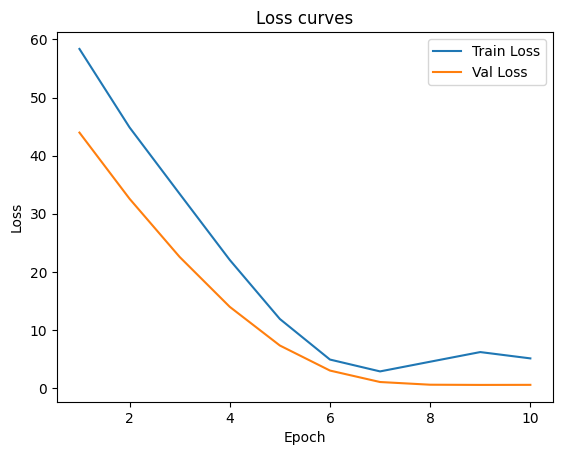

In [27]:
model = BaselineNet(input_features=input_features)

loss_fn = nn.MSELoss() # Changed to MSELoss for regression

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

history = fit(model, train_loader, validation_loader, loss_fn, optimizer, device, epochs=10)

plot_history(history)